# CE 639: AI for Civil Engineering
## Deep Learning Training in Practice: From Forward Pass to Fine-Tuning

**A Unified Hands-On Tutorial**

---

### What This Tutorial Is

You have studied FNN, CNN, and RNN *architectures* in Lectures 10–12.
This tutorial teaches you **how to train them well**.

The red thread is the **4-step training loop** — the same recipe applied consistently
across different data types and architectures:

```
1. Forward pass       →  predictions = model(inputs)
2. Loss computation   →  loss = criterion(predictions, targets)
3. Backward pass      →  loss.backward()
4. Parameter update   →  optimizer.step()
```

By the end you will be able to:
- Write and debug a complete PyTorch training loop from scratch
- Handle tabular data (FNNs), image data (CNNs), and sequence data (RNNs)
- Recognise and fix overfitting, underfitting, and gradient pathologies
- Use a pretrained model and compare it fairly against a scratch model
- Read loss curves and draw correct conclusions

### Structure

| Section | Topic | Data |
|---|---|---|
| 0 | Setup & reproducibility | — |
| 1 | Training loop anatomy | Synthetic 2-D classification |
| 2 | FNN training workflow | Synthetic CE regression |
| 3 | CNN training workflow | FashionMNIST |
| 4 | RNN / temporal workflow | Synthetic sine-wave sequence |
| 5 | Scratch vs pretrained | FashionMNIST + ResNet-18 |
| 6 | Failure modes & diagnostics | (reuse above data) |
| 7 | Summary, cheat sheet & exercises | — |

---
*CE 639: AI for Civil Engineering — IIT Gandhinagar*

*Instructors: Dr. Udit Bhatia & Dr. Sushobhan Sen*

*Tutor: Sarth Dubey*

---
## Section 0: Setup, Imports, and Reproducibility

Before any experiment: fix the random seed, detect the device, and configure plots.
Reproducibility is not optional in scientific computing.

In [ ]:
# ─── Standard scientific stack ────────────────────────────────────────────────
import os
import math
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

# Plotting style — identical to L10/L11/L12
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': [13, 5],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 100,
})

# ─── PyTorch ──────────────────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
    TORCH_OK = True
    print(f"✅ PyTorch {torch.__version__}")
except ImportError:
    TORCH_OK = False
    print("⚠️  PyTorch not found.  Install: pip install torch")

# ─── torchvision ──────────────────────────────────────────────────────────────
try:
    import torchvision
    import torchvision.transforms as transforms
    import torchvision.models as tv_models
    from torchvision.datasets import FashionMNIST
    TV_OK = True
    print(f"✅ torchvision {torchvision.__version__}")
except ImportError:
    TV_OK = False
    print("⚠️  torchvision not found.  Install: pip install torchvision")

# ─── sklearn helpers ──────────────────────────────────────────────────────────
from sklearn.datasets import make_moons, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("✅ numpy, matplotlib, sklearn loaded")

✅ PyTorch 2.10.0+cu128
✅ torchvision 0.25.0+cu128
✅ numpy, matplotlib, sklearn loaded


In [ ]:
# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42

np.random.seed(SEED)
if TORCH_OK:
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Deterministic ops on GPU (optional; may reduce speed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ─── Device ───────────────────────────────────────────────────────────────────
if TORCH_OK:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n🖥️  Device: {DEVICE}")
    if DEVICE.type == 'cuda':
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    else:
        print("   Running on CPU — some cells will be slower.")
        print("   Tip: open in Google Colab for free GPU access.")
else:
    DEVICE = None

# ─── Demo mode flag ───────────────────────────────────────────────────────────
# Set FULL_TRAINING = True to run longer experiments (more epochs, full dataset).
# Default is False for classroom / laptop use.
FULL_TRAINING = False

N_EPOCHS_DEMO  = 5   if not FULL_TRAINING else 30
N_EPOCHS_CNN   = 5   if not FULL_TRAINING else 20
N_EPOCHS_RNN   = 10  if not FULL_TRAINING else 50
DATA_SUBSET    = 5000 if not FULL_TRAINING else 60000   # FashionMNIST samples

print(f"\n⚙️  FULL_TRAINING = {FULL_TRAINING}")
print(f"   N_EPOCHS_DEMO={N_EPOCHS_DEMO}, N_EPOCHS_CNN={N_EPOCHS_CNN}, "
      f"N_EPOCHS_RNN={N_EPOCHS_RNN}")
print(f"   FashionMNIST subset size = {DATA_SUBSET}")
print("\n💡 Set FULL_TRAINING = True for best results (slower).")


🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

⚙️  FULL_TRAINING = False
   N_EPOCHS_DEMO=5, N_EPOCHS_CNN=5, N_EPOCHS_RNN=10
   FashionMNIST subset size = 5000

💡 Set FULL_TRAINING = True for best results (slower).


In [ ]:
# ─── Common utility functions (defined once, used throughout) ─────────────────

def set_seed(seed: int = SEED):
    """Call before each experiment for reproducibility."""
    np.random.seed(seed)
    if TORCH_OK:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def numpy_to_tensor(*arrays, dtype=torch.float32, device=None):
    """Convert numpy arrays to PyTorch tensors on DEVICE."""
    dev = device or DEVICE
    return [torch.tensor(a, dtype=dtype).to(dev) for a in arrays]

def tensor_to_numpy(t):
    return t.detach().cpu().numpy()

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def accuracy(logits_or_probs, targets):
    """Compute classification accuracy (logits → argmax)."""
    preds = logits_or_probs.argmax(dim=1) if logits_or_probs.ndim > 1 else (logits_or_probs > 0).long()
    return (preds == targets).float().mean().item()

print("✅ Utility functions defined.")

✅ Utility functions defined.


---
## Section 1: The Training Loop — Anatomy and Intuition

Before applying the training loop to complex architectures, we study it on the
simplest possible problem: a 2-D binary classification task.

### The 4-Step Loop

```python
for epoch in range(n_epochs):
    model.train()                        # 1. switch to training mode
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()            # 2. clear old gradients
        predictions = model(X_batch)     # 3. forward pass
        loss = criterion(predictions, y_batch)  # 4. compute loss
        loss.backward()                  # 5. backward pass (compute gradients)
        optimizer.step()                 # 6. update weights
```

**Why each line matters:**
- `model.train()` enables Dropout and BatchNorm's training behaviour
- `optimizer.zero_grad()` prevents gradient accumulation across batches
- `loss.backward()` calls PyTorch's autograd engine
- `optimizer.step()` applies the update: θ ← θ − η · ∇L(θ)

### Dataset: Two Moons

A 2-D non-linearly separable dataset. Perfect for studying training dynamics
because we can visualise the decision boundary.

SECTION 1: THE TRAINING LOOP

📊 Two-Moons Dataset:
   Train : 1500 samples | Val: 500 samples
   Classes: [750 750]  (balanced)


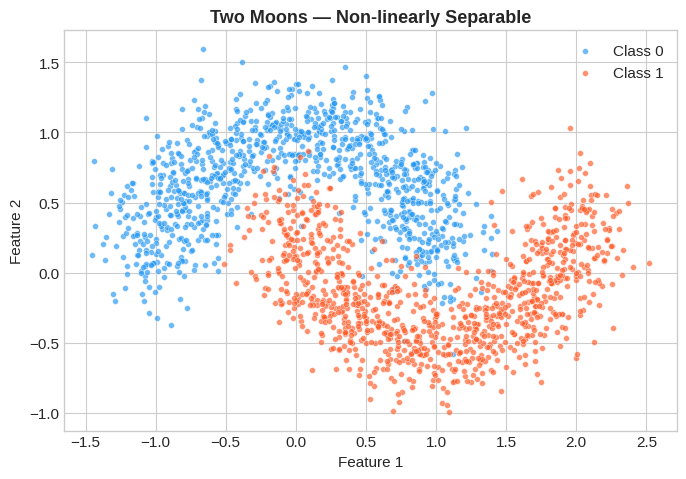


💡 A linear classifier would be ~50% here — we need a nonlinear model.


In [ ]:
# ─── Generate the moons dataset ───────────────────────────────────────────────
print("=" * 65)
print("SECTION 1: THE TRAINING LOOP")
print("=" * 65)

set_seed(42)
X_moons, y_moons = make_moons(n_samples=2000, noise=0.20, random_state=42)

X_tr_m, X_val_m, y_tr_m, y_val_m = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42, stratify=y_moons
)

# Standardise (ALWAYS for neural nets)
sc_m = StandardScaler()
X_tr_m = sc_m.fit_transform(X_tr_m)
X_val_m = sc_m.transform(X_val_m)

print(f"\n📊 Two-Moons Dataset:")
print(f"   Train : {X_tr_m.shape[0]} samples | Val: {X_val_m.shape[0]} samples")
print(f"   Classes: {np.bincount(y_tr_m)}  (balanced)")

# Visualise
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2196F3', '#FF5722']
for cls, col in enumerate(colors):
    mask = y_moons == cls
    ax.scatter(X_moons[mask, 0], X_moons[mask, 1],
               c=col, s=18, alpha=0.65, edgecolors='white', linewidths=0.4,
               label=f'Class {cls}')
ax.set_title('Two Moons — Non-linearly Separable', fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

print("\n💡 A linear classifier would be ~50% here — we need a nonlinear model.")

In [ ]:
# ─── Define a simple 2-layer FNN — everything in this file ─────────────────────

class MoonsFNN(nn.Module):
    """
    Small 2-layer feedforward network for binary classification.
    Defined locally — no imports from utils/.
    """
    def __init__(self, hidden: int = 32, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),           # logits for 2 classes
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# ─── Core training loop — fully explicit, step by step ────────────────────────

def train_loop(model, train_loader, val_loader, optimizer, criterion,
               n_epochs=10, clip_grad=None, verbose=True, device=DEVICE):
    """
    A clean, fully explicit PyTorch training loop.

    Returns a history dict with per-epoch train_loss, val_loss,
    train_acc, val_acc.
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': []}

    for epoch in range(1, n_epochs + 1):
        # ── TRAINING PHASE ────────────────────────────────────────────────────
        model.train()           # activates Dropout / BatchNorm train mode
        running_loss, running_acc = 0.0, 0.0
        n_batches = 0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            optimizer.zero_grad()           # clear previous gradients
            logits = model(X_b)             # forward pass
            loss = criterion(logits, y_b)   # compute loss
            loss.backward()                 # backward pass
            if clip_grad is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()                # update weights

            running_loss += loss.item()
            running_acc  += accuracy(logits.detach(), y_b)
            n_batches += 1

        train_loss = running_loss / n_batches
        train_acc  = running_acc  / n_batches

        # ── VALIDATION PHASE ──────────────────────────────────────────────────
        model.eval()            # disables Dropout, uses running stats for BN
        val_loss_sum, val_acc_sum, val_batches = 0.0, 0.0, 0
        with torch.no_grad():   # no gradient tracking needed
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = model(X_b)
                val_loss_sum += criterion(logits, y_b).item()
                val_acc_sum  += accuracy(logits, y_b)
                val_batches  += 1

        val_loss = val_loss_sum / val_batches
        val_acc  = val_acc_sum  / val_batches

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose and (epoch == 1 or epoch % max(1, n_epochs // 5) == 0):
            print(f"  Epoch {epoch:3d}/{n_epochs}  "
                  f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

    return history


def plot_history(history, title='Training History', figsize=(13, 4)):
    """Plot loss and accuracy curves from a history dict."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].plot(epochs, history['train_loss'], 'b-', lw=2, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-', lw=2, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if 'train_acc' in history:
        axes[1].plot(epochs, history['train_acc'], 'b-', lw=2, label='Train')
        axes[1].plot(epochs, history['val_acc'],   'r-', lw=2, label='Val')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Accuracy Curves'); axes[1].legend()
        axes[1].set_ylim(0, 1.05); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig, axes

EXPERIMENT 1-A: First Training Run on Two-Moons

🏗️  Model: MoonsFNN | Parameters: 1,218
MoonsFNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

🚀 Training for 5 epochs...
  Epoch   1/5  train_loss=0.6291  val_loss=0.5482  train_acc=0.784  val_acc=0.872
  Epoch   2/5  train_loss=0.4900  val_loss=0.4063  train_acc=0.855  val_acc=0.876
  Epoch   3/5  train_loss=0.3701  val_loss=0.3050  train_acc=0.862  val_acc=0.883
  Epoch   4/5  train_loss=0.3010  val_loss=0.2626  train_acc=0.872  val_acc=0.900
  Epoch   5/5  train_loss=0.2741  val_loss=0.2415  train_acc=0.874  val_acc=0.902
   Done in 0.8s


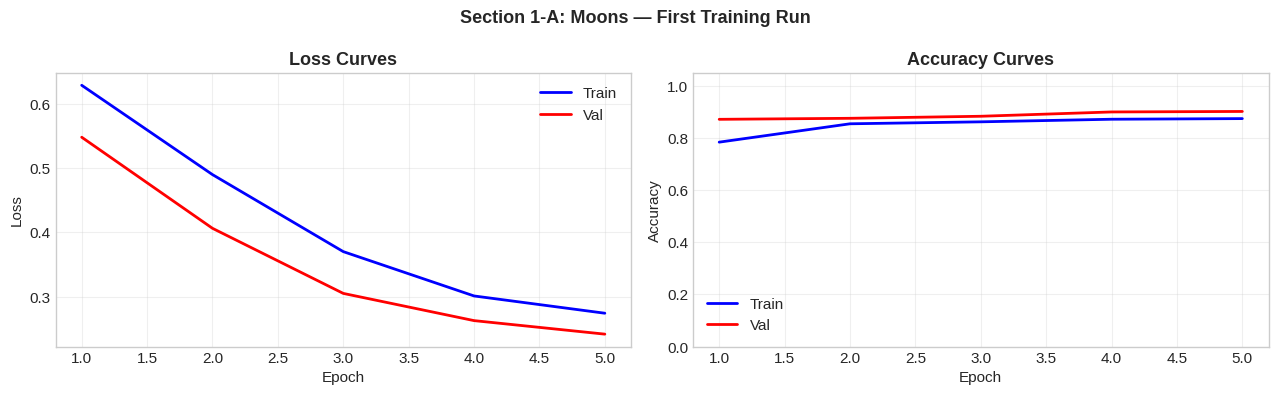

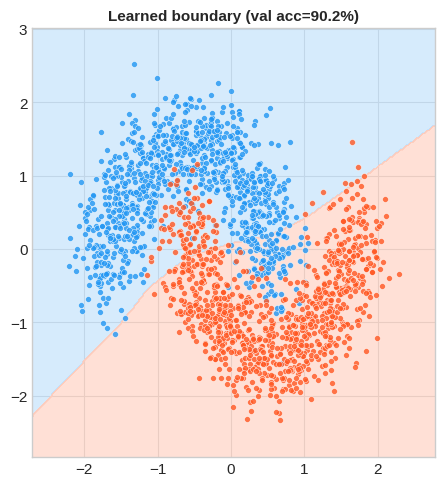


✅ Final: train acc=87.4%  val acc=90.2%


In [ ]:
# ─── Run the first training experiment ───────────────────────────────────────
print("=" * 65)
print("EXPERIMENT 1-A: First Training Run on Two-Moons")
print("=" * 65)

if TORCH_OK:
    set_seed(42)

    # Build DataLoaders
    X_tr_t, y_tr_t = numpy_to_tensor(X_tr_m, y_tr_m.astype(np.int64),
                                      dtype=torch.float32)
    y_tr_t = y_tr_t.long()
    X_val_t, y_val_t = numpy_to_tensor(X_val_m, y_val_m.astype(np.int64),
                                        dtype=torch.float32)
    y_val_t = y_val_t.long()

    ds_tr_m  = TensorDataset(X_tr_t, y_tr_t)
    ds_val_m = TensorDataset(X_val_t, y_val_t)
    dl_tr_m  = DataLoader(ds_tr_m,  batch_size=64, shuffle=True)
    dl_val_m = DataLoader(ds_val_m, batch_size=64, shuffle=False)

    # Build model
    model_m = MoonsFNN(hidden=32, dropout=0.0).to(DEVICE)
    print(f"\n🏗️  Model: MoonsFNN | Parameters: {count_params(model_m):,}")
    print(model_m)

    # Criterion + optimizer
    criterion_m = nn.CrossEntropyLoss()
    optimizer_m = optim.Adam(model_m.parameters(), lr=1e-3)

    print(f"\n🚀 Training for {N_EPOCHS_DEMO} epochs...")
    t0 = time.time()
    history_m = train_loop(model_m, dl_tr_m, dl_val_m,
                            optimizer_m, criterion_m,
                            n_epochs=N_EPOCHS_DEMO, verbose=True)
    print(f"   Done in {time.time()-t0:.1f}s")

    fig, _ = plot_history(history_m, title='Section 1-A: Moons — First Training Run')
    plt.show()

    # Decision boundary
    def plot_decision_boundary(model, X_data, y_data, ax, title=''):
        h = 0.02
        x_min, x_max = X_data[:, 0].min()-0.5, X_data[:, 0].max()+0.5
        y_min, y_max = X_data[:, 1].min()-0.5, X_data[:, 1].max()+0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(DEVICE)
        model.eval()
        with torch.no_grad():
            Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)
        cmap_bg = ListedColormap(['#BBDEFB', '#FFCCBC'])
        ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
        for cls, col in enumerate(['#2196F3', '#FF5722']):
            mask = y_data == cls
            ax.scatter(X_data[mask, 0], X_data[mask, 1], c=col, s=18,
                      edgecolors='white', linewidths=0.4, alpha=0.8)
        ax.set_title(title, fontsize=11)
        ax.set_aspect('equal')

    fig, ax = plt.subplots(figsize=(6, 5))
    plot_decision_boundary(model_m,
                           np.vstack([X_tr_m, X_val_m]),
                           np.concatenate([y_tr_m, y_val_m]), ax,
                           title=f"Learned boundary (val acc={history_m['val_acc'][-1]:.1%})")
    plt.tight_layout(); plt.show()

    print(f"\n✅ Final: train acc={history_m['train_acc'][-1]:.1%}  "
          f"val acc={history_m['val_acc'][-1]:.1%}")

### What to notice

- **Train loss ↓ and Val loss ↓ together** → the model is learning and generalising.
- **Train acc ≈ Val acc** → no significant overfitting with this small model.

The decision boundary is a smooth nonlinear curve — something no linear model can produce.

---

### 1.1 Inside `model.train()` vs `model.eval()`

| Mode | Dropout | BatchNorm | When to use |
|---|---|---|---|
| `model.train()` | Active (drops neurons) | Uses batch statistics | During training |
| `model.eval()` | Disabled (all neurons) | Uses running statistics | Validation, inference |

**Forgetting `model.eval()`** is one of the most common bugs in PyTorch code.
It causes val accuracy to be artificially lower (Dropout randomly drops neurons during eval!).

Let's demonstrate the difference quantitatively.

EXPERIMENT 1-B: model.train() vs model.eval() — the Critical Difference


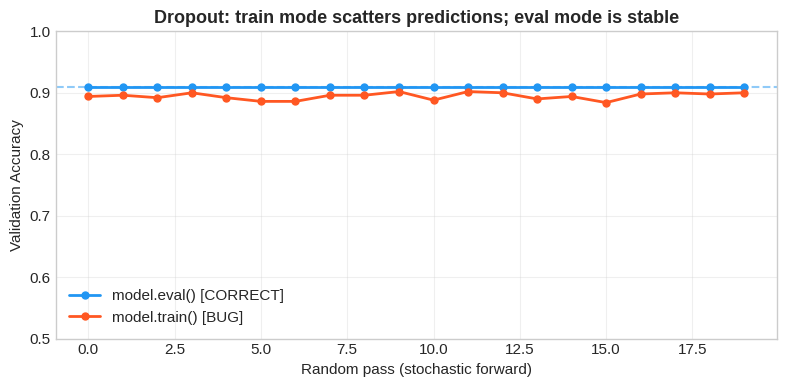


  eval mode  → acc = 0.910 ± 0.0000  (stable ✅)
  train mode → acc = 0.895 ± 0.0055  (noisy ⚠️ — ALWAYS use eval!)


In [ ]:
# ─── model.train() vs model.eval() diagnostic ──────────────────────────────────
print("=" * 65)
print("EXPERIMENT 1-B: model.train() vs model.eval() — the Critical Difference")
print("=" * 65)

if TORCH_OK:
    set_seed(42)
    model_with_drop = MoonsFNN(hidden=64, dropout=0.5).to(DEVICE)
    opt_d = optim.Adam(model_with_drop.parameters(), lr=1e-3)
    _ = train_loop(model_with_drop, dl_tr_m, dl_val_m, opt_d, criterion_m,
                   n_epochs=N_EPOCHS_DEMO, verbose=False)

    # Now check accuracy in train vs eval mode
    results = {}
    X_val_tensor = X_val_t.to(DEVICE)
    y_val_np = y_val_m

    for mode_name, use_train in [("model.eval() [CORRECT]", False),
                                  ("model.train() [BUG]", True)]:
        accs = []
        for _ in range(20):       # average over 20 stochastic passes
            if use_train:
                model_with_drop.train()
            else:
                model_with_drop.eval()
            with torch.no_grad():
                logits = model_with_drop(X_val_tensor)
            preds = logits.argmax(1).cpu().numpy()
            accs.append(np.mean(preds == y_val_np))
        results[mode_name] = accs

    fig, ax = plt.subplots(figsize=(8, 4))
    for label, accs in results.items():
        color = '#2196F3' if 'CORRECT' in label else '#FF5722'
        ax.plot(accs, 'o-', color=color, lw=2, markersize=5, label=label)
    ax.axhline(np.mean(results["model.eval() [CORRECT]"]), color='#2196F3',
               linestyle='--', alpha=0.5)
    ax.set_xlabel('Random pass (stochastic forward)')
    ax.set_ylabel('Validation Accuracy')
    ax.set_title('Dropout: train mode scatters predictions; eval mode is stable',
                 fontweight='bold')
    ax.legend(); ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"\n  eval mode  → acc = {np.mean(results['model.eval() [CORRECT]']):.3f} ± "
          f"{np.std(results['model.eval() [CORRECT]']):.4f}  (stable ✅)")
    print(f"  train mode → acc = {np.mean(results['model.train() [BUG]']):.3f} ± "
          f"{np.std(results['model.train() [BUG]']):.4f}  (noisy ⚠️ — ALWAYS use eval!)")

EXPERIMENT 1-C: Learning Rate Sensitivity


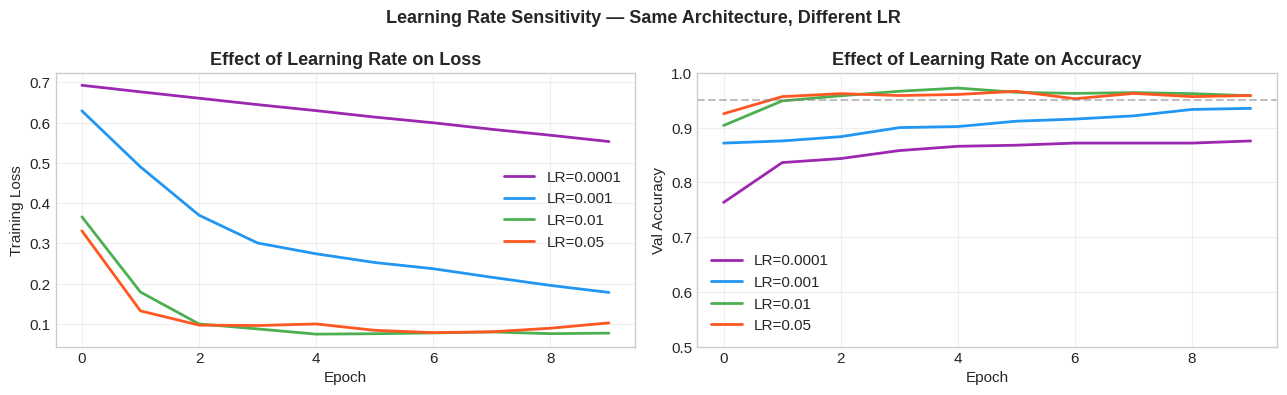


  Final val accuracy by LR:
    LR=1e-04:  0.876  ← too slow
    LR=1e-03:  0.935  
    LR=1e-02:  0.958  
    LR=5e-02:  0.959  ← may diverge

💡 Key Insight:
   • LR too small → slow convergence, may not reach best accuracy in given epochs
   • LR too large → noisy / divergent training
   • Start with LR=1e-3 for Adam (the reliable default)


In [ ]:
# ─── Experiment 1-C: Learning Rate Sensitivity ───────────────────────────────
print("=" * 65)
print("EXPERIMENT 1-C: Learning Rate Sensitivity")
print("=" * 65)

if TORCH_OK:
    lrs_to_test = [1e-4, 1e-3, 1e-2, 5e-2]
    colors_lr = ['#9C27B0', '#2196F3', '#4CAF50', '#FF5722']
    histories_lr = {}

    for lr_val in lrs_to_test:
        set_seed(42)
        m = MoonsFNN(hidden=32).to(DEVICE)
        opt = optim.Adam(m.parameters(), lr=lr_val)
        h = train_loop(m, dl_tr_m, dl_val_m, opt, criterion_m,
                       n_epochs=N_EPOCHS_DEMO * 2, verbose=False)
        histories_lr[lr_val] = h

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for (lr_val, h), col in zip(histories_lr.items(), colors_lr):
        label = f'LR={lr_val}'
        axes[0].plot(h['train_loss'], '-', color=col, lw=2, label=label)
        axes[1].plot(h['val_acc'],    '-', color=col, lw=2, label=label)

    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
    axes[0].set_title('Effect of Learning Rate on Loss'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
    axes[1].set_title('Effect of Learning Rate on Accuracy'); axes[1].legend()
    axes[1].set_ylim(0.5, 1.0); axes[1].grid(True, alpha=0.3)
    axes[1].axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='95% target')

    plt.suptitle('Learning Rate Sensitivity — Same Architecture, Different LR',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print("\n  Final val accuracy by LR:")
    for lr_val, h in histories_lr.items():
        final = h['val_acc'][-1]
        note = '← too slow' if lr_val == 1e-4 else ('← may diverge' if lr_val >= 5e-2 else '')
        print(f"    LR={lr_val:.0e}:  {final:.3f}  {note}")

    print("\n💡 Key Insight:")
    print("   • LR too small → slow convergence, may not reach best accuracy in given epochs")
    print("   • LR too large → noisy / divergent training")
    print("   • Start with LR=1e-3 for Adam (the reliable default)")

EXPERIMENT 1-D: Batch Size Effect


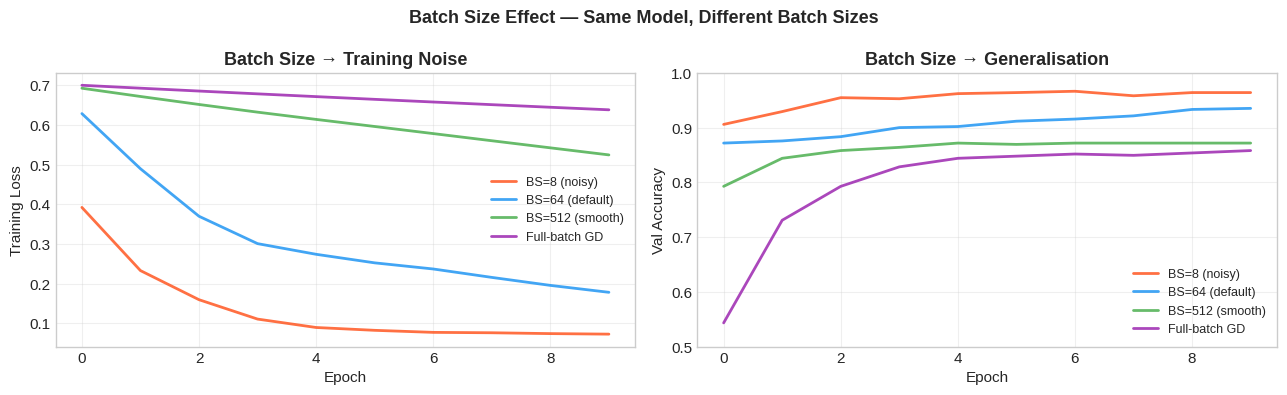


💡 Key Insight:
   • Small batches: noisy gradients, but act as regulariser (often good val acc)
   • Large batches: smooth gradients, fast per-epoch, but can overfit more easily
   • Full-batch GD: exact gradients, but very slow and can get stuck in sharp minima
   • Practical default: 64–256 for most tasks


In [ ]:
# ─── Experiment 1-D: Batch Size Effect ───────────────────────────────────────
print("=" * 65)
print("EXPERIMENT 1-D: Batch Size Effect")
print("=" * 65)

if TORCH_OK:
    batch_sizes = [8, 64, 512, len(ds_tr_m)]   # last = full-batch GD
    labels_bs   = ['BS=8 (noisy)', 'BS=64 (default)', 'BS=512 (smooth)', 'Full-batch GD']
    colors_bs   = ['#FF5722', '#2196F3', '#4CAF50', '#9C27B0']
    histories_bs = {}

    for bs, lbl in zip(batch_sizes, labels_bs):
        set_seed(42)
        dl_tr_bs = DataLoader(ds_tr_m, batch_size=bs, shuffle=True)
        m_bs = MoonsFNN(hidden=32).to(DEVICE)
        opt_bs = optim.Adam(m_bs.parameters(), lr=1e-3)
        h_bs = train_loop(m_bs, dl_tr_bs, dl_val_m, opt_bs, criterion_m,
                          n_epochs=N_EPOCHS_DEMO * 2, verbose=False)
        histories_bs[lbl] = h_bs

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for (lbl, h), col in zip(histories_bs.items(), colors_bs):
        axes[0].plot(h['train_loss'], '-', color=col, lw=2, label=lbl, alpha=0.85)
        axes[1].plot(h['val_acc'],    '-', color=col, lw=2, label=lbl, alpha=0.85)

    for ax, ylabel, title in zip(axes,
            ['Training Loss', 'Val Accuracy'],
            ['Batch Size → Training Noise', 'Batch Size → Generalisation']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    axes[1].set_ylim(0.5, 1.0)

    plt.suptitle('Batch Size Effect — Same Model, Different Batch Sizes',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print("\n💡 Key Insight:")
    print("   • Small batches: noisy gradients, but act as regulariser (often good val acc)")
    print("   • Large batches: smooth gradients, fast per-epoch, but can overfit more easily")
    print("   • Full-batch GD: exact gradients, but very slow and can get stuck in sharp minima")
    print("   • Practical default: 64–256 for most tasks")

EXPERIMENT 1-E: Gradient Statistics (Looking Inside the Loop)


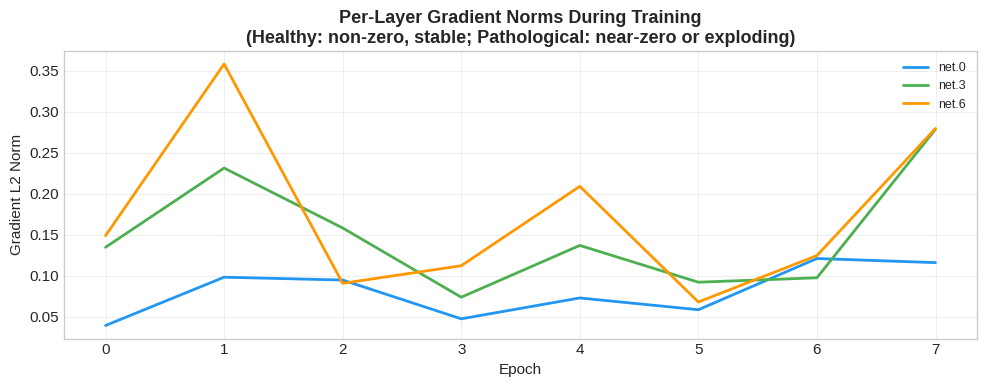


  Final gradient norms per layer:
    net.0.weight                       : 0.11580  ✅ OK
    net.3.weight                       : 0.27849  ✅ OK
    net.6.weight                       : 0.27942  ✅ OK

💡 Key Insight:
   • Gradient norms should be non-zero (learning is happening)
   • Very small norms (<1e-6) → vanishing gradient problem
   • Very large norms (>100) → exploding gradient problem
   • Section 6 will stress-test both failure modes.


In [ ]:
# ─── Gradient statistics — looking inside the training loop ──────────────────
print("=" * 65)
print("EXPERIMENT 1-E: Gradient Statistics (Looking Inside the Loop)")
print("=" * 65)

if TORCH_OK:
    # Train for a few epochs and record gradient norms per layer
    set_seed(42)
    model_g = MoonsFNN(hidden=32).to(DEVICE)
    opt_g = optim.Adam(model_g.parameters(), lr=1e-3)
    criterion_g = nn.CrossEntropyLoss()

    grad_history = {name: [] for name, p in model_g.named_parameters()
                    if p.requires_grad and 'weight' in name}
    n_epochs_g = max(N_EPOCHS_DEMO, 8)

    for epoch in range(n_epochs_g):
        model_g.train()
        for X_b, y_b in dl_tr_m:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_g.zero_grad()
            loss_g = criterion_g(model_g(X_b), y_b)
            loss_g.backward()
            opt_g.step()
        # Record gradient norms after last batch of each epoch
        for name, p in model_g.named_parameters():
            if name in grad_history and p.grad is not None:
                grad_history[name].append(p.grad.norm().item())

    fig, ax = plt.subplots(figsize=(10, 4))
    layer_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
    for (name, norms), col in zip(grad_history.items(), layer_colors):
        ax.plot(norms, '-', color=col, lw=2, label=name.replace('.weight', ''))
    ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient L2 Norm')
    ax.set_title('Per-Layer Gradient Norms During Training\n'
                 '(Healthy: non-zero, stable; Pathological: near-zero or exploding)',
                 fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    final_norms = {name: norms[-1] for name, norms in grad_history.items()}
    print("\n  Final gradient norms per layer:")
    for name, norm in final_norms.items():
        health = "✅ OK" if 1e-4 < norm < 10.0 else "⚠️ Check"
        print(f"    {name:<35}: {norm:.5f}  {health}")

    print("\n💡 Key Insight:")
    print("   • Gradient norms should be non-zero (learning is happening)")
    print("   • Very small norms (<1e-6) → vanishing gradient problem")
    print("   • Very large norms (>100) → exploding gradient problem")
    print("   • Section 6 will stress-test both failure modes.")

### Section 1 Summary

You have now seen every component of the training loop in detail.

| Concept | What you observed |
|---|---|
| 4-step loop | Forward → Loss → Backward → Update |
| `model.train()` vs `model.eval()` | Dropout behaves differently — always switch modes |
| Learning rate | Too small = slow; too large = diverges; 1e-3 Adam is a safe default |
| Batch size | Small = noisy but regularising; large = smooth but may overfit |
| Gradient norms | Primary diagnostic for healthy vs pathological training |

**The same loop runs unchanged whether your model is an FNN, CNN, or RNN.**
The next three sections apply it to different data types and architectures.

---
## Section 2: FNN Training Workflow — Tabular CE Data

**Dataset:** Synthetic RC Beam Deflection (same physics as Lecture 10 §17, generated inline).

**Task:** Predict midspan deflection δ (mm) from 6 structural parameters.

**Goal of this section:** Learn the complete FNN training pipeline —
data normalisation → DataLoader → model → loss → training loop →
overfitting → regularisation → early stopping → checkpointing → evaluation.

In [ ]:
print("=" * 65)
print("SECTION 2: FNN TRAINING WORKFLOW — TABULAR CE DATA")
print("=" * 65)

# ─── Inline dataset generator ─────────────────────────────────────────────────
def generate_beam_dataset(n: int = 2000, noise_frac: float = 0.05,
                           random_state: int = 42) -> tuple:
    """
    Synthetic RC beam deflection dataset.
    Physics: δ = PL³ / (48 E I_eff)  where I_eff depends on cracking.

    Features: [P (kN), L (m), E (GPa), I_gross (cm⁴), M_cr (kN·m), ρ (%)]
    Target  : δ (mm)
    """
    rng = np.random.default_rng(random_state)

    P      = rng.uniform(10, 200,   n)   # Applied load (kN)
    L      = rng.uniform(3,  10,    n)   # Span (m)
    E      = rng.uniform(20, 35,    n)   # Young's modulus (GPa)
    I_g    = rng.uniform(500, 5000, n)   # Gross moment of inertia (cm⁴)
    M_cr   = rng.uniform(5,   80,   n)   # Cracking moment (kN·m)
    rho    = rng.uniform(0.5, 3.0,  n)   # Reinforcement ratio (%)

    # Effective stiffness (piecewise: uncracked if M_applied < M_cr)
    M_applied = P * L / 4
    I_eff = np.where(M_applied < M_cr,
                     I_g,
                     I_g * (M_cr / M_applied)**2 + I_g * 0.1)  # simplified

    # δ in mm  (unit conversions: L in m→mm, E in GPa→kN/mm², I in cm⁴→mm⁴)
    delta = (P * (L * 1000)**3) / (48 * E * I_eff * 1e4) * 1e-3
    noise = rng.normal(0, noise_frac * delta.std(), n)
    delta = np.clip(delta + noise, 0, None)

    X = np.column_stack([P, L, E, I_g, M_cr, rho])
    return X, delta

set_seed(42)
X_beam, y_beam = generate_beam_dataset(n=2000, noise_frac=0.05)

X_tr_b, X_val_b, y_tr_b, y_val_b = train_test_split(
    X_beam, y_beam, test_size=0.20, random_state=42
)

print(f"\n📊 RC Beam Dataset:")
print(f"   Features: [P, L, E, I_gross, M_cr, ρ]  (6 structural parameters)")
print(f"   Target  : δ  (midspan deflection, mm)")
print(f"   Train   : {X_tr_b.shape[0]}  |  Val: {X_val_b.shape[0]}")
print(f"   δ range : [{y_beam.min():.1f}, {y_beam.max():.1f}] mm")

SECTION 2: FNN TRAINING WORKFLOW — TABULAR CE DATA

📊 RC Beam Dataset:
   Features: [P, L, E, I_gross, M_cr, ρ]  (6 structural parameters)
   Target  : δ  (midspan deflection, mm)
   Train   : 1600  |  Val: 400
   δ range : [0.0, 221.3] mm


In [ ]:
# ─── Step 2.1: Standard data pipeline ────────────────────────────────────────
print("\n─── Step 2.1: Preprocessing ─────────────────────────────────────────────")

sc_X_b = StandardScaler()
sc_y_b = StandardScaler()

X_tr_bs  = sc_X_b.fit_transform(X_tr_b)         # fit only on train!
X_val_bs = sc_X_b.transform(X_val_b)            # apply same stats to val

y_tr_bs  = sc_y_b.fit_transform(y_tr_b.reshape(-1, 1)).ravel()
y_val_bs = sc_y_b.transform(y_val_b.reshape(-1, 1)).ravel()

print(f"   X_train (raw)  : mean={X_tr_b.mean():.1f}, std={X_tr_b.std():.1f}")
print(f"   X_train (scaled): mean={X_tr_bs.mean():.4f}, std={X_tr_bs.std():.4f}")
print("   ✅ StandardScaler fitted on train, applied to val (no data leakage!)")

if TORCH_OK:
    # TensorDataset + DataLoader
    X_tr_bt = torch.tensor(X_tr_bs,  dtype=torch.float32)
    y_tr_bt = torch.tensor(y_tr_bs,  dtype=torch.float32).unsqueeze(1)
    X_val_bt = torch.tensor(X_val_bs, dtype=torch.float32)
    y_val_bt = torch.tensor(y_val_bs, dtype=torch.float32).unsqueeze(1)

    ds_tr_b  = TensorDataset(X_tr_bt, y_tr_bt)
    ds_val_b = TensorDataset(X_val_bt, y_val_bt)
    dl_tr_b  = DataLoader(ds_tr_b,  batch_size=64, shuffle=True)
    dl_val_b = DataLoader(ds_val_b, batch_size=64, shuffle=False)

    print(f"\n   DataLoader: batch_size=64, shuffle=True for train")
    print(f"   Batches per epoch: {len(dl_tr_b)}")


─── Step 2.1: Preprocessing ─────────────────────────────────────────────
   X_train (raw)  : mean=492.7, std=1152.2
   X_train (scaled): mean=-0.0000, std=1.0000
   ✅ StandardScaler fitted on train, applied to val (no data leakage!)

   DataLoader: batch_size=64, shuffle=True for train
   Batches per epoch: 25


In [ ]:
# ─── Step 2.2: Define a configurable FNN regression model ─────────────────────

class BeamFNN(nn.Module):
    """
    Configurable FNN for regression.
    Supports: variable depth, width, dropout, batch normalisation.
    """
    def __init__(self, in_features: int = 6, hidden_dims: list = [64, 32],
                 dropout: float = 0.0, batch_norm: bool = False):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))   # regression output (no activation)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
# ─── Step 2.3: Regression training loop variant ───────────────────────────────

def train_regression(model, train_loader, val_loader, optimizer, criterion,
                     n_epochs=20, device=DEVICE, verbose=True,
                     scheduler=None, patience=None):
    """
    Training loop adapted for regression tasks.
    Tracks MSE loss + optional early stopping.
    Returns history and the best model state dict.
    """
    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')
    best_state = None
    no_improve_count = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        tr_loss, n_b = 0.0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item(); n_b += 1

        model.eval()
        val_loss, n_vb = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_loss += criterion(model(X_b), y_b).item(); n_vb += 1

        epoch_tr  = tr_loss / n_b
        epoch_val = val_loss / n_vb
        history['train_loss'].append(epoch_tr)
        history['val_loss'].append(epoch_val)

        if scheduler is not None:
            scheduler.step(epoch_val)

        if epoch_val < best_val:
            best_val = epoch_val
            best_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if verbose and (epoch == 1 or epoch % max(1, n_epochs // 5) == 0):
            print(f"  Epoch {epoch:3d}/{n_epochs}  "
                  f"train={epoch_tr:.4f}  val={epoch_val:.4f}  "
                  f"best_val={best_val:.4f}")

        if patience is not None and no_improve_count >= patience:
            print(f"  ⏹ Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    return history, best_state


─── Step 2.4: Baseline FNN Training ─────────────────────────────────────

🏗️  BeamFNN [64, 32] | Parameters: 2,561
🚀 Training for 20 epochs...
  Epoch   1/20  train=0.7963  val=0.8737  best_val=0.8737
  Epoch   4/20  train=0.2132  val=0.2521  best_val=0.2521
  Epoch   8/20  train=0.1070  val=0.1484  best_val=0.1484
  Epoch  12/20  train=0.0691  val=0.1021  best_val=0.1021
  Epoch  16/20  train=0.0520  val=0.0844  best_val=0.0844
  Epoch  20/20  train=0.0411  val=0.0756  best_val=0.0756

📊 Baseline Results: RMSE=5.51 mm, R²=0.9395


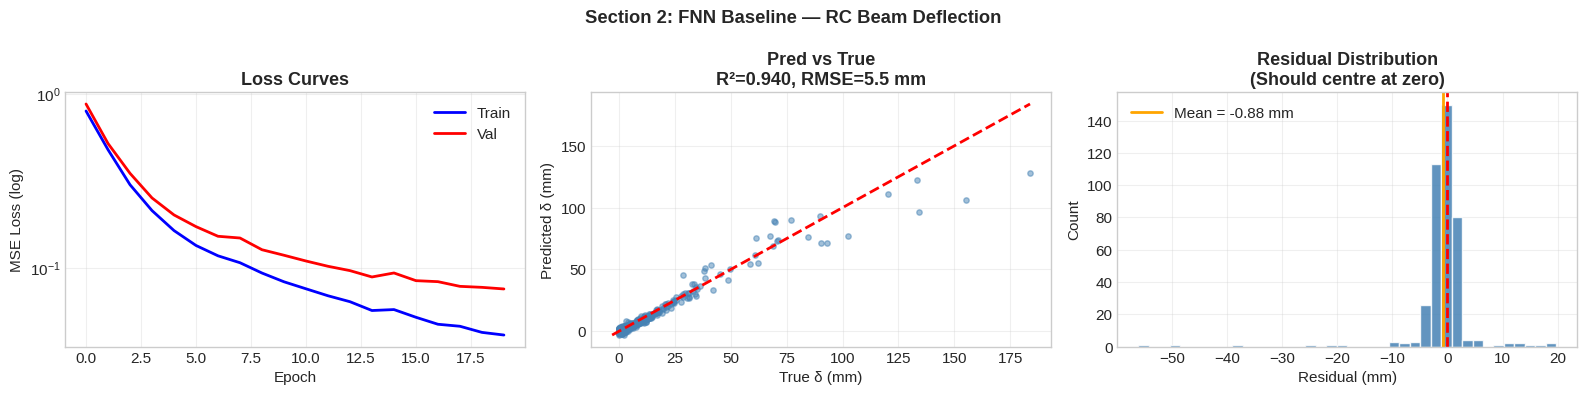

In [ ]:
# ─── Step 2.4: First training run ────────────────────────────────────────────
print("\n─── Step 2.4: Baseline FNN Training ─────────────────────────────────────")

if TORCH_OK:
    set_seed(42)
    n_ep_beam = max(N_EPOCHS_DEMO * 4, 20)

    model_b1 = BeamFNN(hidden_dims=[64, 32]).to(DEVICE)
    print(f"\n🏗️  BeamFNN [64, 32] | Parameters: {count_params(model_b1):,}")

    criterion_b = nn.MSELoss()
    opt_b1 = optim.Adam(model_b1.parameters(), lr=1e-3)

    print(f"🚀 Training for {n_ep_beam} epochs...")
    hist_b1, _ = train_regression(model_b1, dl_tr_b, dl_val_b,
                                   opt_b1, criterion_b,
                                   n_epochs=n_ep_beam, verbose=True)

    # Evaluate
    model_b1.eval()
    with torch.no_grad():
        y_pred_s = model_b1(X_val_bt.to(DEVICE)).cpu().numpy().ravel()
    y_pred_b1 = sc_y_b.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    rmse_b1 = np.sqrt(np.mean((y_val_b - y_pred_b1)**2))
    r2_b1   = 1 - np.sum((y_val_b - y_pred_b1)**2) / np.sum((y_val_b - y_val_b.mean())**2)

    print(f"\n📊 Baseline Results: RMSE={rmse_b1:.2f} mm, R²={r2_b1:.4f}")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].semilogy(hist_b1['train_loss'], 'b-', lw=2, label='Train')
    axes[0].semilogy(hist_b1['val_loss'],   'r-', lw=2, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss (log)')
    axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].scatter(y_val_b, y_pred_b1, s=15, alpha=0.5, c='steelblue')
    lims = [min(y_val_b.min(), y_pred_b1.min()), max(y_val_b.max(), y_pred_b1.max())]
    axes[1].plot(lims, lims, 'r--', lw=2)
    axes[1].set_xlabel('True δ (mm)'); axes[1].set_ylabel('Predicted δ (mm)')
    axes[1].set_title(f'Pred vs True\nR²={r2_b1:.3f}, RMSE={rmse_b1:.1f} mm')
    axes[1].grid(True, alpha=0.3)

    residuals = y_pred_b1 - y_val_b
    axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[2].axvline(0, color='red', lw=2, linestyle='--')
    axes[2].axvline(residuals.mean(), color='orange', lw=2,
                    label=f'Mean = {residuals.mean():.2f} mm')
    axes[2].set_xlabel('Residual (mm)'); axes[2].set_ylabel('Count')
    axes[2].set_title('Residual Distribution\n(Should centre at zero)')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle('Section 2: FNN Baseline — RC Beam Deflection', fontweight='bold')
    plt.tight_layout(); plt.show()


─── Step 2.5: Overfitting Demonstration ─────────────────────────────────

  Big model:  430,593 parameters on 100 samples (ratio = 4306×!)
  Final  train MSE: 0.00360
  Final  val   MSE: 0.16859
  Gap: 47× worse on val → OVERFITTING


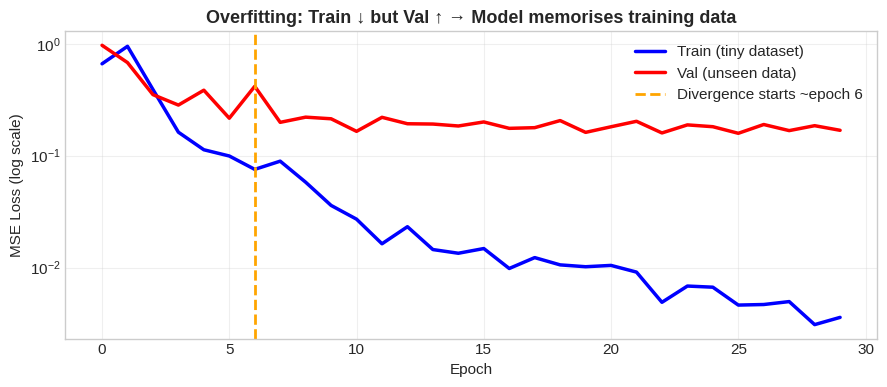


💡 To fix: use more data, L2 regularisation, Dropout, or Early Stopping.


In [ ]:
# ─── Step 2.5: Intentional overfitting — seeing the problem ───────────────────
print("\n─── Step 2.5: Overfitting Demonstration ─────────────────────────────────")

if TORCH_OK:
    set_seed(42)
    # Use SMALL training set (100 samples) + LARGE model → classic overfitting setup
    n_small = 100
    ds_tiny  = Subset(ds_tr_b, list(range(n_small)))
    dl_tiny  = DataLoader(ds_tiny, batch_size=32, shuffle=True)

    model_overfit = BeamFNN(hidden_dims=[512, 512, 256, 128]).to(DEVICE)
    print(f"\n  Big model:  {count_params(model_overfit):,} parameters on {n_small} samples"
          f" (ratio = {count_params(model_overfit)/n_small:.0f}×!)")

    opt_ov = optim.Adam(model_overfit.parameters(), lr=1e-3)
    n_ep_ov = max(N_EPOCHS_DEMO * 6, 30)
    hist_ov, _ = train_regression(model_overfit, dl_tiny, dl_val_b,
                                   opt_ov, criterion_b, n_epochs=n_ep_ov, verbose=False)

    print(f"  Final  train MSE: {hist_ov['train_loss'][-1]:.5f}")
    print(f"  Final  val   MSE: {hist_ov['val_loss'][-1]:.5f}")
    print(f"  Gap: {hist_ov['val_loss'][-1]/hist_ov['train_loss'][-1]:.0f}× worse on val → OVERFITTING")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(hist_ov['train_loss'], 'b-', lw=2.5, label='Train (tiny dataset)')
    ax.semilogy(hist_ov['val_loss'],   'r-', lw=2.5, label='Val (unseen data)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (log scale)')
    ax.set_title('Overfitting: Train ↓ but Val ↑ → Model memorises training data',
                 fontweight='bold')

    # Annotate the divergence
    diverge_epoch = next((i for i in range(1, len(hist_ov['val_loss']))
                          if hist_ov['val_loss'][i] > hist_ov['val_loss'][i-1] * 1.5), None)
    if diverge_epoch:
        ax.axvline(diverge_epoch, color='orange', linestyle='--', lw=2,
                   label=f'Divergence starts ~epoch {diverge_epoch}')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\n💡 To fix: use more data, L2 regularisation, Dropout, or Early Stopping.")


─── Step 2.6: Regularisation Comparison ─────────────────────────────────


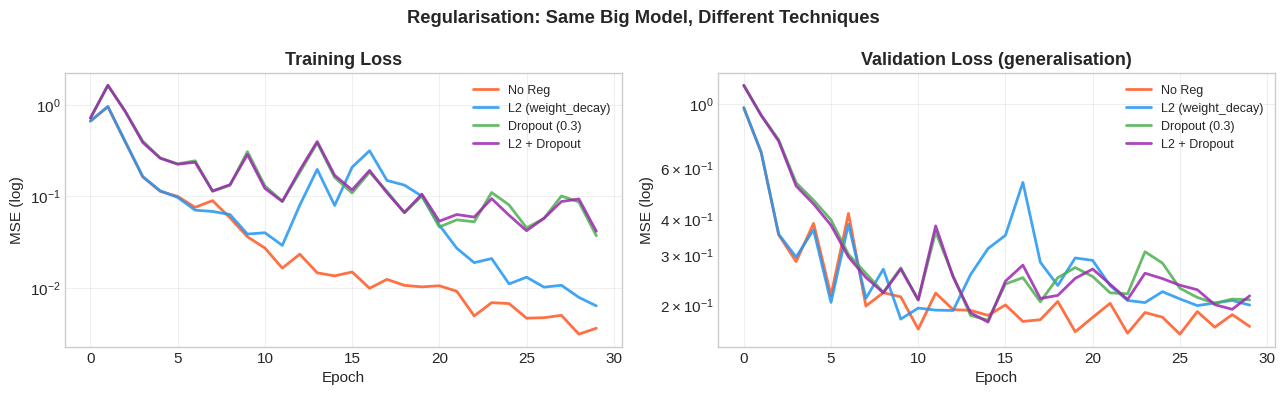


  Best regularisation strategy: 'No Reg'
  → Val MSE = 0.16859

💡 L2 + Dropout together is usually more effective than either alone.


In [ ]:
# ─── Step 2.6: Regularisation cures ──────────────────────────────────────────
print("\n─── Step 2.6: Regularisation Comparison ─────────────────────────────────")

if TORCH_OK:
    reg_configs = {
        'No Reg':              dict(dropout=0.0, batch_norm=False, weight_decay=0.0),
        'L2 (weight_decay)':   dict(dropout=0.0, batch_norm=False, weight_decay=1e-3),
        'Dropout (0.3)':       dict(dropout=0.3, batch_norm=False, weight_decay=0.0),
        'L2 + Dropout':        dict(dropout=0.3, batch_norm=False, weight_decay=1e-3),
    }
    reg_colors = ['#FF5722', '#2196F3', '#4CAF50', '#9C27B0']
    reg_histories = {}

    for (label, cfg), col in zip(reg_configs.items(), reg_colors):
        set_seed(42)
        m_reg = BeamFNN(hidden_dims=[512, 512, 256, 128],
                        dropout=cfg['dropout'],
                        batch_norm=cfg['batch_norm']).to(DEVICE)
        opt_reg = optim.Adam(m_reg.parameters(), lr=1e-3,
                              weight_decay=cfg['weight_decay'])
        h_reg, _ = train_regression(m_reg, dl_tiny, dl_val_b, opt_reg, criterion_b,
                                     n_epochs=n_ep_ov, verbose=False)
        reg_histories[label] = h_reg

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for (label, h), col in zip(reg_histories.items(), reg_colors):
        axes[0].semilogy(h['train_loss'], '-', color=col, lw=2, label=label, alpha=0.85)
        axes[1].semilogy(h['val_loss'],   '-', color=col, lw=2, label=label, alpha=0.85)

    for ax, title, ylabel in zip(axes,
            ['Training Loss', 'Validation Loss (generalisation)'],
            ['MSE (log)', 'MSE (log)']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.suptitle('Regularisation: Same Big Model, Different Techniques',
                 fontweight='bold')
    plt.tight_layout(); plt.show()

    best_label = min(reg_histories, key=lambda k: reg_histories[k]['val_loss'][-1])
    print(f"\n  Best regularisation strategy: '{best_label}'")
    print(f"  → Val MSE = {reg_histories[best_label]['val_loss'][-1]:.5f}")
    print("\n💡 L2 + Dropout together is usually more effective than either alone.")


─── Step 2.7: Early Stopping + Checkpointing ────────────────────────────

  Training with Early Stopping (patience=10, up to 40 epochs)...
  Epoch   1/40  train=0.8115  val=0.8988  best_val=0.8988
  Epoch   8/40  train=0.1543  val=0.1625  best_val=0.1625
  Epoch  16/40  train=0.0863  val=0.1056  best_val=0.1056
  Epoch  24/40  train=0.0713  val=0.0800  best_val=0.0800
  Epoch  32/40  train=0.0644  val=0.0728  best_val=0.0670
  Epoch  40/40  train=0.0586  val=0.0577  best_val=0.0577

  ✅ Loaded best model weights (lowest val loss = 0.05767 at epoch 40)

  💾 Checkpoint saved to: /tmp/beam_best_model.pth
     Contents: model weights, optimizer state, scaler params
     → Load with: torch.load('/tmp/beam_best_model.pth')


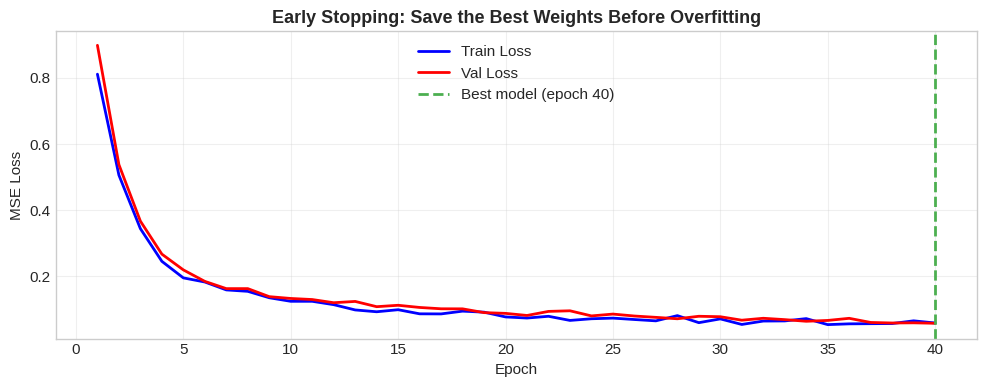

In [ ]:
# ─── Step 2.7: Early stopping + model checkpointing ──────────────────────────
print("\n─── Step 2.7: Early Stopping + Checkpointing ────────────────────────────")

if TORCH_OK:
    set_seed(42)
    model_es = BeamFNN(hidden_dims=[64, 32], dropout=0.1).to(DEVICE)
    opt_es = optim.Adam(model_es.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_es = optim.lr_scheduler.ReduceLROnPlateau(
        opt_es, mode='min', factor=0.5, patience=5
    )

    n_ep_es = max(N_EPOCHS_DEMO * 8, 40)
    print(f"\n  Training with Early Stopping (patience=10, up to {n_ep_es} epochs)...")
    hist_es, best_state_es = train_regression(
        model_es, dl_tr_b, dl_val_b, opt_es, criterion_b,
        n_epochs=n_ep_es, verbose=True,
        scheduler=scheduler_es, patience=10
    )

    # Restore best weights
    model_es.load_state_dict(best_state_es)
    print(f"\n  ✅ Loaded best model weights (lowest val loss = "
          f"{min(hist_es['val_loss']):.5f} at epoch "
          f"{hist_es['val_loss'].index(min(hist_es['val_loss']))+1})")

    # Save checkpoint
    checkpoint_path = '/tmp/beam_best_model.pth'
    torch.save({
        'model_state_dict':     best_state_es,
        'optimizer_state_dict': opt_es.state_dict(),
        'val_loss':             min(hist_es['val_loss']),
        'scale_X_mean':         sc_X_b.mean_,
        'scale_X_std':          sc_X_b.scale_,
        'scale_y_mean':         sc_y_b.mean_,
        'scale_y_std':          sc_y_b.scale_,
    }, checkpoint_path)
    print(f"\n  💾 Checkpoint saved to: {checkpoint_path}")
    print(f"     Contents: model weights, optimizer state, scaler params")
    print(f"     → Load with: torch.load('{checkpoint_path}')")

    # Plot with early stopping annotation
    best_epoch = hist_es['val_loss'].index(min(hist_es['val_loss'])) + 1
    fig, ax = plt.subplots(figsize=(10, 4))
    epochs_es = range(1, len(hist_es['train_loss']) + 1)
    ax.plot(epochs_es, hist_es['train_loss'], 'b-', lw=2, label='Train Loss')
    ax.plot(epochs_es, hist_es['val_loss'],   'r-', lw=2, label='Val Loss')
    ax.axvline(best_epoch, color='#4CAF50', linestyle='--', lw=2,
               label=f'Best model (epoch {best_epoch})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_title('Early Stopping: Save the Best Weights Before Overfitting',
                 fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

In [ ]:
# ─── Section 2 Summary ────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("SECTION 2 SUMMARY: FNN Tabular Workflow")
print("=" * 65)

pipeline_steps = [
    ("1. Generate / load data",     "→ numpy arrays X (n, features), y (n,)"),
    ("2. Train/val split",          "→ NEVER use val data for fitting scalers"),
    ("3. Standardise (fit on tr)", "→ StandardScaler().fit_transform(X_train)"),
    ("4. TensorDataset + DataLoader","→ batch_size=64, shuffle=True (train only)"),
    ("5. Define model (nn.Module)", "→ fully inline, no imports from utils/"),
    ("6. Loss + optimiser",         "→ MSELoss + Adam(lr=1e-3, weight_decay=λ)"),
    ("7. Training loop",            "→ train() / eval() / zero_grad / backward / step"),
    ("8. Early stopping",           "→ track best val loss, patience counter"),
    ("9. Checkpointing",            "→ torch.save(state_dict, path)"),
    ("10. Evaluate",                "→ RMSE, R², pred vs true scatter, residuals"),
]

print("\n  Standard tabular FNN pipeline:")
for step, detail in pipeline_steps:
    print(f"  {step:<40}  {detail}")

print("\n🔑 The 3 golden rules for tabular data:")
print("   1. ALWAYS StandardScaler — inputs AND targets for regression")
print("   2. Early stopping + best checkpointing is cheap insurance against overfitting")
print("   3. Inspect residuals, not just R² — systematic bias reveals model limits")


SECTION 2 SUMMARY: FNN Tabular Workflow

  Standard tabular FNN pipeline:
  1. Generate / load data                   → numpy arrays X (n, features), y (n,)
  2. Train/val split                        → NEVER use val data for fitting scalers
  3. Standardise (fit on tr)                → StandardScaler().fit_transform(X_train)
  4. TensorDataset + DataLoader             → batch_size=64, shuffle=True (train only)
  5. Define model (nn.Module)               → fully inline, no imports from utils/
  6. Loss + optimiser                       → MSELoss + Adam(lr=1e-3, weight_decay=λ)
  7. Training loop                          → train() / eval() / zero_grad / backward / step
  8. Early stopping                         → track best val loss, patience counter
  9. Checkpointing                          → torch.save(state_dict, path)
  10. Evaluate                              → RMSE, R², pred vs true scatter, residuals

🔑 The 3 golden rules for tabular data:
   1. ALWAYS StandardScaler — input

---
## Section 3: CNN Training Workflow — Image Data (FashionMNIST)

**Dataset:** FashionMNIST — 70k grayscale images (28×28) of clothing items, 10 classes.

**Why FashionMNIST over MNIST?**
More challenging than MNIST (digits), but same size and format.
Closer to real CE image tasks (textured surfaces, multiple categories).

**What's new compared to FNNs:**
1. Images need `transforms` (ToTensor, Normalize)
2. Data augmentation artificially expands the dataset
3. Convolutions preserve spatial structure
4. Feature maps let you see *what* the network learned

In [ ]:
print("=" * 65)
print("SECTION 3: CNN TRAINING WORKFLOW — IMAGE DATA")
print("=" * 65)

# ─── 3.1 Load FashionMNIST with transforms ────────────────────────────────────

FMNIST_CLASSES = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal',     'Shirt',   'Sneaker',  'Bag',   'Boot']

if TV_OK and TORCH_OK:
    # Standard normalisation for FashionMNIST (mean=0.286, std=0.353)
    FMNIST_MEAN, FMNIST_STD = 0.2860, 0.3530

    transform_base = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(FMNIST_MEAN,), std=(FMNIST_STD,)),
    ])

    transform_augment = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=(FMNIST_MEAN,), std=(FMNIST_STD,)),
    ])

    print(f"\n📥 Loading FashionMNIST...")
    try:
        ds_fmnist_train_full = FashionMNIST(
            root='/tmp/fmnist', train=True, download=True, transform=transform_base
        )
        ds_fmnist_test_full = FashionMNIST(
            root='/tmp/fmnist', train=False, download=True, transform=transform_base
        )
        TV_DATA_OK = True
        print(f"   ✅ Downloaded: {len(ds_fmnist_train_full)} train, "
              f"{len(ds_fmnist_test_full)} test images")
    except Exception as e:
        TV_DATA_OK = False
        print(f"   ⚠️ Download failed: {e}")
        print("   Generating synthetic placeholder images instead.")
else:
    TV_DATA_OK = False

SECTION 3: CNN TRAINING WORKFLOW — IMAGE DATA

📥 Loading FashionMNIST...


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]

   ✅ Downloaded: 60000 train, 10000 test images



📊 FashionMNIST Subset (FULL_TRAINING=False):
   Train: 5000 images  |  Test: 10000 images
   Classes: ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']
   Image size: 28×28 (grayscale, 1 channel)


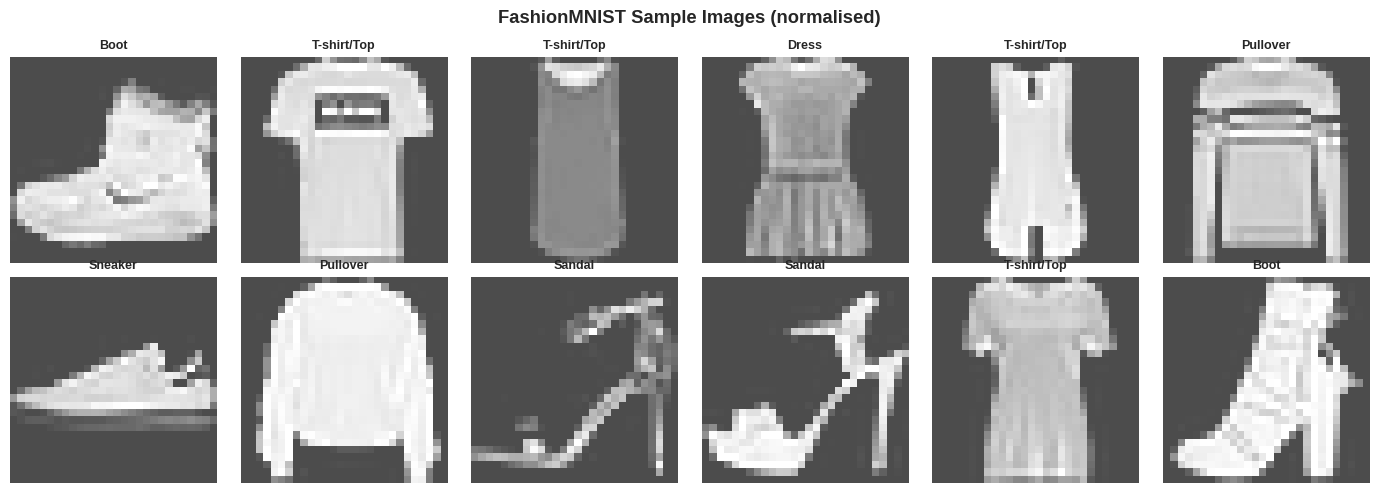

In [ ]:
# Subsample for demo mode
if TV_DATA_OK:
    indices = list(range(DATA_SUBSET))
    ds_fmnist_train = Subset(ds_fmnist_train_full, indices)
    ds_fmnist_test  = ds_fmnist_test_full   # always use full test for fair eval

    dl_fmnist_train = DataLoader(ds_fmnist_train, batch_size=64,
                                  shuffle=True,  num_workers=0)
    dl_fmnist_test  = DataLoader(ds_fmnist_test,  batch_size=128,
                                  shuffle=False, num_workers=0)

    print(f"\n📊 FashionMNIST Subset (FULL_TRAINING={FULL_TRAINING}):")
    print(f"   Train: {len(ds_fmnist_train)} images  |  Test: {len(ds_fmnist_test)} images")
    print(f"   Classes: {FMNIST_CLASSES}")
    print(f"   Image size: 28×28 (grayscale, 1 channel)")

    # Show samples
    sample_imgs, sample_labels = zip(*[ds_fmnist_train_full[i] for i in range(12)])
    sample_imgs = [img.squeeze() for img in sample_imgs]

    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    axes = axes.flatten()
    for i, (img, lbl) in enumerate(zip(sample_imgs, sample_labels)):
        axes[i].imshow(img, cmap='gray', vmin=-2, vmax=2)
        axes[i].set_title(FMNIST_CLASSES[lbl], fontsize=9)
        axes[i].axis('off')
    plt.suptitle('FashionMNIST Sample Images (normalised)', fontweight='bold')
    plt.tight_layout(); plt.show()

In [ ]:
# ─── 3.2 CNN architecture — defined inline ────────────────────────────────────

class SimpleCNN(nn.Module):
    """
    Simple 2-block CNN for FashionMNIST.
    Architecture: [Conv→BN→ReLU→Pool] × 2 → Flatten → FC → FC
    All code inline — no utils/ import.
    """
    def __init__(self, n_classes: int = 10, dropout: float = 0.3):
        super().__init__()
        # Block 1: 1 channel → 32 filters
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28×28×32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 14×14×32
            nn.Dropout2d(dropout * 0.5),
        )
        # Block 2: 32 → 64 filters
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14×14×64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 7×7×64
            nn.Dropout2d(dropout * 0.5),
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(7 * 7 * 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

    def get_features(self, x):
        """Return intermediate feature maps from block1."""
        return self.block1[:3](x)   # after Conv+BN+ReLU (before Pool)

if TV_DATA_OK and TORCH_OK:
    cnn_model = SimpleCNN(n_classes=10, dropout=0.3).to(DEVICE)
    print(f"\n🏗️  SimpleCNN | Parameters: {count_params(cnn_model):,}")
    print(cnn_model)

    # Test forward pass
    dummy = torch.zeros(1, 1, 28, 28).to(DEVICE)
    out = cnn_model(dummy)
    print(f"\n   Forward pass: {dummy.shape} → {out.shape} ✅")


🏗️  SimpleCNN | Parameters: 824,650
SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

   Forward pass: torch.Size([


─── Step 3.3: Training the CNN ──────────────────────────────────────────

🚀 Training SimpleCNN for 5 epochs on 5000 images...
  Epoch  1/5  train_loss=0.8453  test_acc=0.806  lr=9.05e-04
  Epoch  2/5  train_loss=0.5139  test_acc=0.825  lr=6.58e-04
  Epoch  3/5  train_loss=0.4405  test_acc=0.809  lr=3.52e-04
  Epoch  4/5  train_loss=0.3729  test_acc=0.853  lr=1.05e-04
  Epoch  5/5  train_loss=0.3325  test_acc=0.860  lr=1.00e-05

   Training time: 16.4s
   Final test accuracy: 86.0%


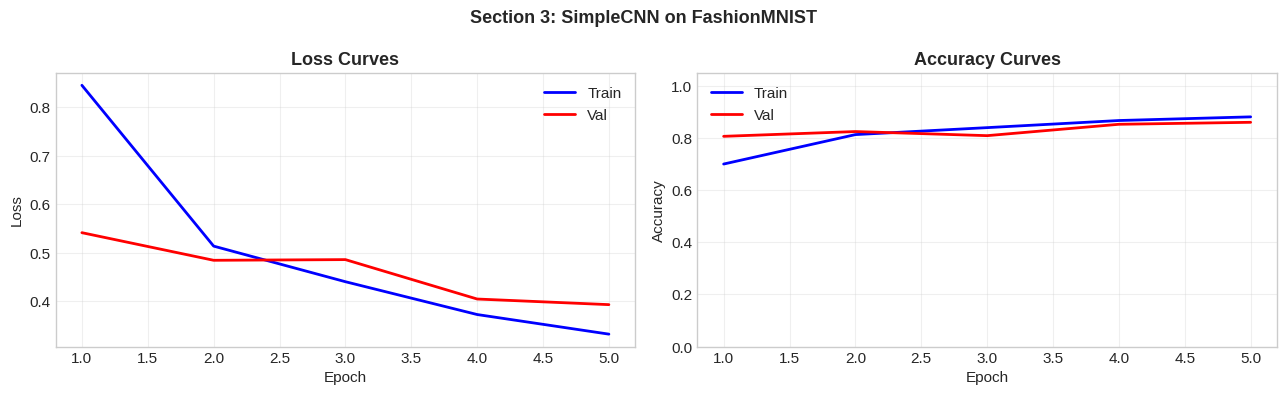

In [ ]:
# ─── 3.3 Training a CNN — same loop, new data ────────────────────────────────
print("\n─── Step 3.3: Training the CNN ──────────────────────────────────────────")

if TV_DATA_OK and TORCH_OK:
    set_seed(42)
    cnn_model = SimpleCNN(n_classes=10, dropout=0.3).to(DEVICE)
    criterion_cnn = nn.CrossEntropyLoss()
    opt_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(
        opt_cnn, T_max=N_EPOCHS_CNN, eta_min=1e-5
    )

    print(f"\n🚀 Training SimpleCNN for {N_EPOCHS_CNN} epochs on "
          f"{len(ds_fmnist_train)} images...")
    t0_cnn = time.time()

    hist_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, N_EPOCHS_CNN + 1):
        cnn_model.train()
        tr_loss, tr_acc, n_b = 0.0, 0.0, 0
        for imgs, labels in dl_fmnist_train:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_cnn.zero_grad()
            logits = cnn_model(imgs)
            loss = criterion_cnn(logits, labels)
            loss.backward()
            opt_cnn.step()
            tr_loss += loss.item(); tr_acc += accuracy(logits.detach(), labels); n_b += 1

        scheduler_cnn.step()

        cnn_model.eval()
        val_loss, val_acc, n_vb = 0.0, 0.0, 0
        with torch.no_grad():
            for imgs, labels in dl_fmnist_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = cnn_model(imgs)
                val_loss += criterion_cnn(logits, labels).item()
                val_acc  += accuracy(logits, labels); n_vb += 1

        hist_cnn['train_loss'].append(tr_loss / n_b)
        hist_cnn['val_loss'].append(val_loss / n_vb)
        hist_cnn['train_acc'].append(tr_acc / n_b)
        hist_cnn['val_acc'].append(val_acc / n_vb)

        print(f"  Epoch {epoch:2d}/{N_EPOCHS_CNN}  "
              f"train_loss={tr_loss/n_b:.4f}  test_acc={val_acc/n_vb:.3f}  "
              f"lr={opt_cnn.param_groups[0]['lr']:.2e}")

    print(f"\n   Training time: {time.time()-t0_cnn:.1f}s")
    print(f"   Final test accuracy: {hist_cnn['val_acc'][-1]:.1%}")

    fig, _ = plot_history(hist_cnn, title='Section 3: SimpleCNN on FashionMNIST')
    plt.show()


─── Step 3.4: Data Augmentation Experiment ──────────────────────────────


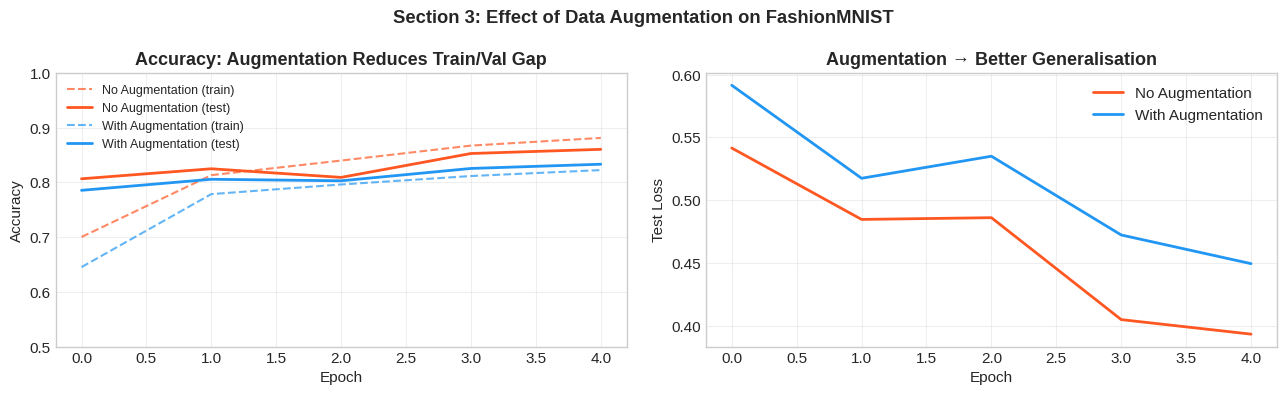


  No Augmentation : test acc = 86.0%
  With Augmentation: test acc = 83.3%
  Improvement: -2.7 percentage points

💡 Augmentation is most helpful when dataset is small or model is large.


In [ ]:
# ─── 3.4 Data augmentation comparison ────────────────────────────────────────
print("\n─── Step 3.4: Data Augmentation Experiment ──────────────────────────────")

if TV_DATA_OK and TORCH_OK:
    # Reload with augmentation transforms
    ds_fmnist_aug = Subset(
        FashionMNIST('/tmp/fmnist', train=True, download=False,
                     transform=transform_augment),
        indices
    )
    dl_fmnist_aug = DataLoader(ds_fmnist_aug, batch_size=64,
                                shuffle=True, num_workers=0)

    set_seed(42)
    cnn_aug = SimpleCNN(n_classes=10, dropout=0.3).to(DEVICE)
    opt_aug = optim.Adam(cnn_aug.parameters(), lr=1e-3, weight_decay=1e-4)

    hist_aug = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, N_EPOCHS_CNN + 1):
        cnn_aug.train()
        tr_loss_a, tr_acc_a, n_b = 0.0, 0.0, 0
        for imgs, labels in dl_fmnist_aug:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_aug.zero_grad()
            logits = cnn_aug(imgs); loss = criterion_cnn(logits, labels)
            loss.backward(); opt_aug.step()
            tr_loss_a += loss.item(); tr_acc_a += accuracy(logits.detach(), labels); n_b += 1

        cnn_aug.eval()
        vl, va, nvb = 0.0, 0.0, 0
        with torch.no_grad():
            for imgs, labels in dl_fmnist_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = cnn_aug(imgs)
                vl += criterion_cnn(logits, labels).item()
                va += accuracy(logits, labels); nvb += 1
        hist_aug['train_loss'].append(tr_loss_a / n_b)
        hist_aug['val_loss'].append(vl / nvb)
        hist_aug['train_acc'].append(tr_acc_a / n_b)
        hist_aug['val_acc'].append(va / nvb)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for (h, label, col) in [(hist_cnn, 'No Augmentation', '#FF5722'),
                              (hist_aug, 'With Augmentation', '#2196F3')]:
        axes[0].plot(h['train_acc'], '--', color=col, lw=1.5, alpha=0.7,
                    label=f'{label} (train)')
        axes[0].plot(h['val_acc'],   '-',  color=col, lw=2,
                    label=f'{label} (test)')
        axes[1].plot(h['val_loss'],  '-',  color=col, lw=2, label=label)

    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy: Augmentation Reduces Train/Val Gap')
    axes[0].set_ylim(0.5, 1.0); axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Loss')
    axes[1].set_title('Augmentation → Better Generalisation')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Section 3: Effect of Data Augmentation on FashionMNIST',
                 fontweight='bold')
    plt.tight_layout(); plt.show()

    improvement = hist_aug['val_acc'][-1] - hist_cnn['val_acc'][-1]
    print(f"\n  No Augmentation : test acc = {hist_cnn['val_acc'][-1]:.1%}")
    print(f"  With Augmentation: test acc = {hist_aug['val_acc'][-1]:.1%}")
    print(f"  Improvement: {improvement*100:+.1f} percentage points")
    print("\n💡 Augmentation is most helpful when dataset is small or model is large.")


─── Step 3.5: Confusion Matrix + Error Analysis ─────────────────────────


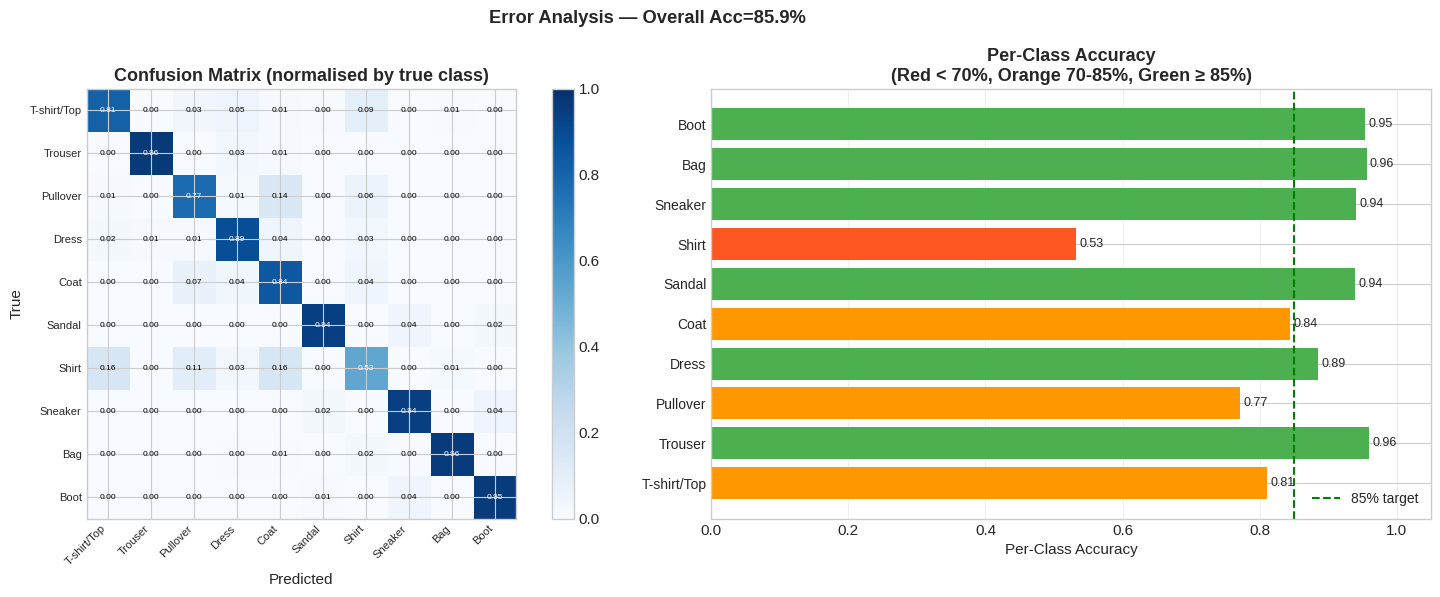


  Most confused class pairs:
    True: Pullover        → Predicted as: Coat  (141 errors)
    True: Shirt           → Predicted as: T-shirt/Top  (157 errors)
    True: Shirt           → Predicted as: Coat  (159 errors)

💡 Shirt↔T-shirt/Pullover confusion is expected — they look similar!


In [ ]:
# ─── 3.5 Confusion matrix + error analysis ────────────────────────────────────
print("\n─── Step 3.5: Confusion Matrix + Error Analysis ─────────────────────────")

if TV_DATA_OK and TORCH_OK:
    all_preds, all_true = [], []
    cnn_model.eval()
    with torch.no_grad():
        for imgs, labels in dl_fmnist_test:
            imgs = imgs.to(DEVICE)
            preds = cnn_model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds); all_true.extend(labels.numpy())
    all_preds, all_true = np.array(all_preds), np.array(all_true)

    cm = confusion_matrix(all_true, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im0 = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
    axes[0].set_xticklabels(FMNIST_CLASSES, rotation=45, ha='right', fontsize=8)
    axes[0].set_yticklabels(FMNIST_CLASSES, fontsize=8)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix (normalised by true class)')
    plt.colorbar(im0, ax=axes[0])
    for i in range(10):
        for j in range(10):
            val = cm_norm[i, j]
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=6, color='white' if val > 0.5 else 'black')

    # Per-class accuracy
    class_accs = cm_norm.diagonal()
    bars = axes[1].barh(range(10), class_accs,
                         color=['#4CAF50' if a >= 0.85 else '#FF9800' if a >= 0.70
                                else '#FF5722' for a in class_accs])
    axes[1].set_yticks(range(10)); axes[1].set_yticklabels(FMNIST_CLASSES, fontsize=10)
    axes[1].axvline(0.85, color='green', linestyle='--', lw=1.5, label='85% target')
    axes[1].set_xlim(0, 1.05); axes[1].set_xlabel('Per-Class Accuracy')
    axes[1].set_title('Per-Class Accuracy\n(Red < 70%, Orange 70-85%, Green ≥ 85%)')
    axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3, axis='x')
    for i, acc in enumerate(class_accs):
        axes[1].text(acc + 0.005, i, f'{acc:.2f}', va='center', fontsize=9)

    plt.suptitle(f'Error Analysis — Overall Acc={np.mean(all_preds==all_true):.1%}',
                 fontweight='bold')
    plt.tight_layout(); plt.show()

    # Find most confused pairs
    np.fill_diagonal(cm, 0)
    top_confused = np.unravel_index(cm.argsort(axis=None)[-3:], cm.shape)
    print("\n  Most confused class pairs:")
    for true_c, pred_c in zip(*top_confused):
        print(f"    True: {FMNIST_CLASSES[true_c]:<15} → Predicted as: "
              f"{FMNIST_CLASSES[pred_c]}  ({cm[true_c, pred_c]} errors)")
    print("\n💡 Shirt↔T-shirt/Pullover confusion is expected — they look similar!")


─── Step 3.6: Feature Map Visualisation ─────────────────────────────────


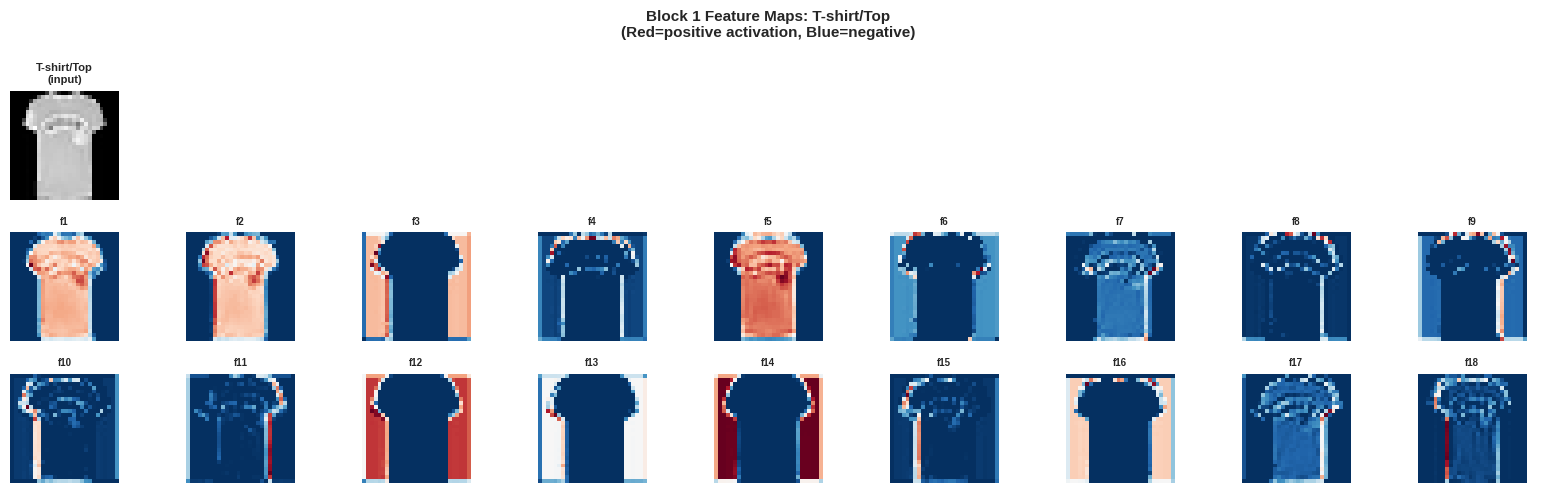

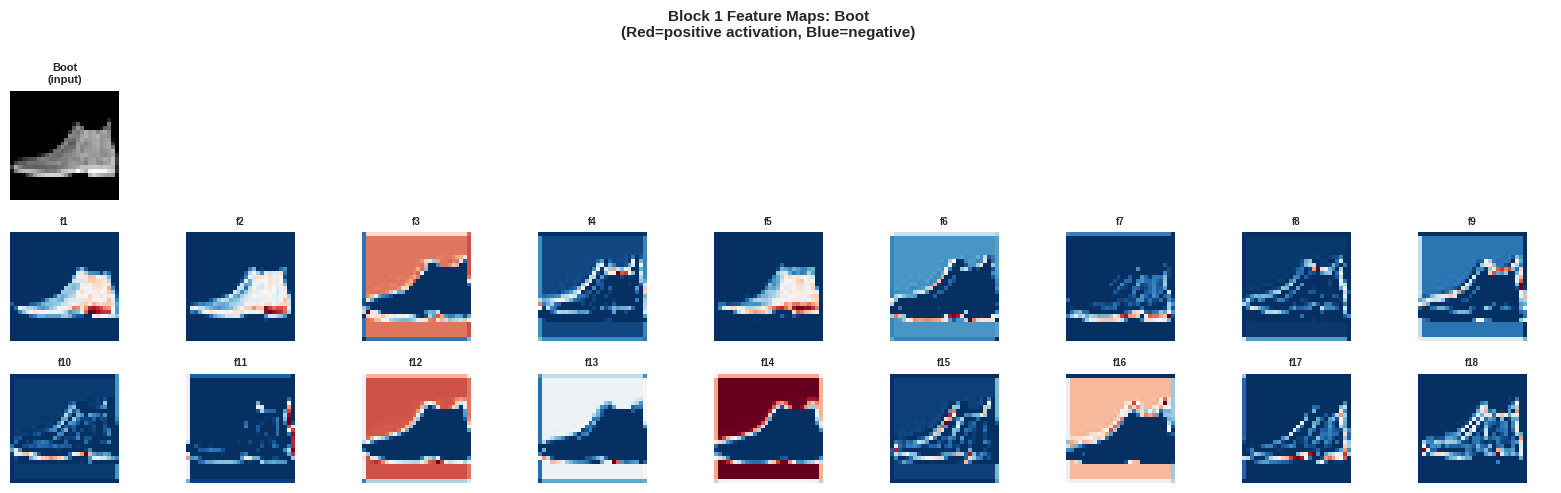


💡 Each filter detects a different texture or edge orientation.
   The pattern of activations is what distinguishes the classes.


In [ ]:
# ─── 3.6 Feature map visualisation ───────────────────────────────────────────
print("\n─── Step 3.6: Feature Map Visualisation ─────────────────────────────────")

if TV_DATA_OK and TORCH_OK:
    # Take one example image from each of 2 classes
    for target_class in [FMNIST_CLASSES.index('T-shirt/Top'),
                          FMNIST_CLASSES.index('Boot')]:
        # find sample
        idx = next(i for i, (_, l) in enumerate(ds_fmnist_test_full) if l == target_class)
        img_raw, label_raw = ds_fmnist_test_full[idx]
        img_tensor = img_raw.unsqueeze(0).to(DEVICE)   # (1,1,28,28)

        cnn_model.eval()
        with torch.no_grad():
            feature_maps = cnn_model.get_features(img_tensor)  # (1,32,28,28)
        feature_maps = feature_maps.squeeze(0).cpu()   # (32,28,28)

        fig, axes = plt.subplots(3, 9, figsize=(16, 5))
        # Original image
        axes[0, 0].imshow(img_raw.squeeze(), cmap='gray')
        axes[0, 0].set_title(f'{FMNIST_CLASSES[label_raw]}\n(input)', fontsize=8)
        axes[0, 0].axis('off')
        for ax in axes[0, 1:]:
            ax.axis('off')

        # First 16 feature maps (rows 1 and 2)
        for i, ax in enumerate(axes[1].tolist() + axes[2].tolist()):
            if i < min(feature_maps.shape[0], 18):
                fm = feature_maps[i].numpy()
                ax.imshow(fm, cmap='RdBu_r')
                ax.set_title(f'f{i+1}', fontsize=7)
            ax.axis('off')

        plt.suptitle(f'Block 1 Feature Maps: {FMNIST_CLASSES[label_raw]}\n'
                     '(Red=positive activation, Blue=negative)',
                     fontweight='bold', fontsize=11)
        plt.tight_layout(); plt.show()

    print("\n💡 Each filter detects a different texture or edge orientation.")
    print("   The pattern of activations is what distinguishes the classes.")

In [ ]:
print("\n" + "=" * 65)
print("SECTION 3 SUMMARY: CNN Workflow")
print("=" * 65)

print("""
  ✅ Loaded FashionMNIST with torchvision transforms (ToTensor, Normalize)
  ✅ Defined SimpleCNN with BatchNorm + Dropout + CosineAnnealingLR — inline
  ✅ Same 4-step training loop as Section 1 — architecture changes, loop stays same
  ✅ Data augmentation reduces overfitting (especially for small dataset subsets)
  ✅ Confusion matrix reveals which classes the model struggles with
  ✅ Feature maps show what each filter learned (edges, textures)

  Key differences vs FNN:
  • Data pipeline: transforms instead of StandardScaler
  • Model: Conv + Pool blocks replace Linear blocks
  • Augmentation: image-specific (flip, rotate, color jitter)
  • Evaluation: per-class accuracy + confusion matrix (not just RMSE)
""")


SECTION 3 SUMMARY: CNN Workflow

  ✅ Loaded FashionMNIST with torchvision transforms (ToTensor, Normalize)
  ✅ Defined SimpleCNN with BatchNorm + Dropout + CosineAnnealingLR — inline
  ✅ Same 4-step training loop as Section 1 — architecture changes, loop stays same
  ✅ Data augmentation reduces overfitting (especially for small dataset subsets)
  ✅ Confusion matrix reveals which classes the model struggles with
  ✅ Feature maps show what each filter learned (edges, textures)

  Key differences vs FNN:
  • Data pipeline: transforms instead of StandardScaler
  • Model: Conv + Pool blocks replace Linear blocks
  • Augmentation: image-specific (flip, rotate, color jitter)
  • Evaluation: per-class accuracy + confusion matrix (not just RMSE)



---
## Section 4: RNN / Temporal Workflow — Sequence Data

**Dataset:** Synthetic multi-frequency damped sine wave (generated inline).

**Task:** One-step-ahead prediction from a sliding window of past values.

**What's new compared to FNNs/CNNs:**
1. Data must be **windowed** into (input_window, target) pairs
2. The train/val split must be **temporal** — never shuffle past/future
3. The model processes inputs **one time step at a time**
4. Gradients can explode — **gradient clipping** is essential
5. Lookback length `L` is a key domain-informed hyperparameter

SECTION 4: RNN TRAINING WORKFLOW — SEQUENCE DATA


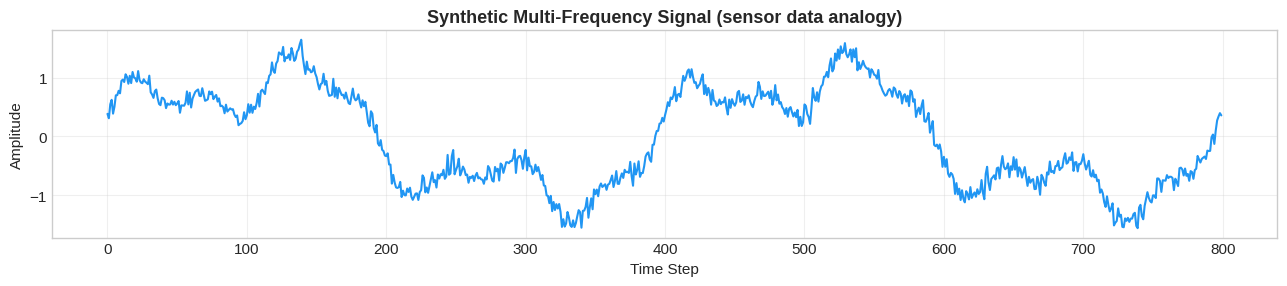


📊 Signal: 800 time steps
   Components: sin(t) + 0.5·sin(3t+π/4) + 0.25·sin(7t) + Gaussian noise


In [ ]:
print("=" * 65)
print("SECTION 4: RNN TRAINING WORKFLOW — SEQUENCE DATA")
print("=" * 65)

# ─── 4.1 Generate synthetic temporal signal ──────────────────────────────────

def generate_sine_signal(n_steps: int = 1000, random_state: int = 42) -> np.ndarray:
    """
    Multi-frequency damped sine wave with noise.
    Mimics a hydraulic sensor or vibration signal.
    """
    rng = np.random.default_rng(random_state)
    t = np.linspace(0, 4 * np.pi, n_steps)
    # Three frequency components + damping
    signal = (np.sin(t)
              + 0.5 * np.sin(3 * t + np.pi / 4)
              + 0.25 * np.sin(7 * t)
              + rng.normal(0, 0.1, n_steps))
    return signal.astype(np.float32)

set_seed(42)
n_seq_steps = 800
raw_signal = generate_sine_signal(n_steps=n_seq_steps)

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(raw_signal, color='#2196F3', lw=1.5)
ax.set_xlabel('Time Step'); ax.set_ylabel('Amplitude')
ax.set_title('Synthetic Multi-Frequency Signal (sensor data analogy)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n📊 Signal: {n_seq_steps} time steps")
print(f"   Components: sin(t) + 0.5·sin(3t+π/4) + 0.25·sin(7t) + Gaussian noise")


─── Step 4.2: Sequence Windowing ────────────────────────────────────────

  Lookback L = 30 steps
  Windows total  : 770
  Train windows  : 616   (first 80% in time)
  Val  windows   : 154  (last 20% in time)

  ⚠️  TEMPORAL SPLIT — never shuffle across train/val boundary!
     Shuffling would mix future data into training → data leakage!


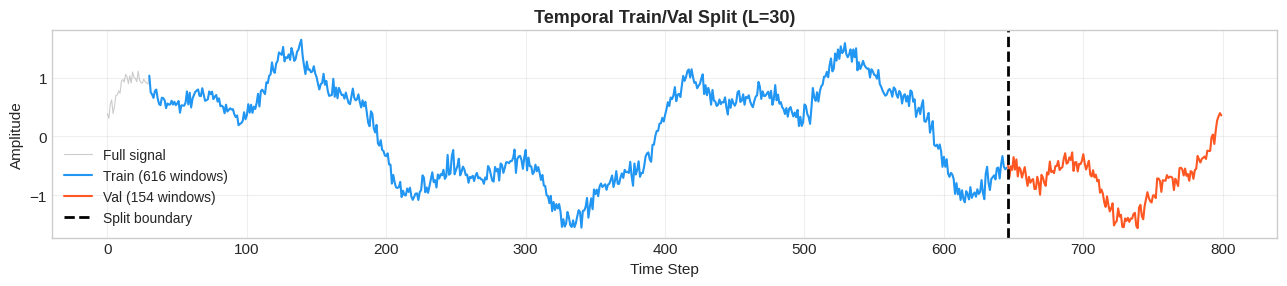

In [ ]:
# ─── 4.2 Sequence windowing ───────────────────────────────────────────────────
print("\n─── Step 4.2: Sequence Windowing ────────────────────────────────────────")

def make_sequences(signal: np.ndarray, lookback: int, horizon: int = 1):
    """
    Sliding window over a 1-D time series.
    Input  X[t]: signal[t : t+lookback]       shape (lookback,)
    Target y[t]: signal[t+lookback : t+lookback+horizon]
    """
    X, y = [], []
    for t in range(len(signal) - lookback - horizon + 1):
        X.append(signal[t : t + lookback])
        y.append(signal[t + lookback : t + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

LOOKBACK = 30    # predict from last 30 steps
X_seq, y_seq = make_sequences(raw_signal, lookback=LOOKBACK)

# ── Temporal split (chronological — NO SHUFFLING across boundary!) ────────────
split_idx = int(0.8 * len(X_seq))

X_tr_seq, X_val_seq = X_seq[:split_idx],   X_seq[split_idx:]
y_tr_seq, y_val_seq = y_seq[:split_idx],   y_seq[split_idx:]

print(f"\n  Lookback L = {LOOKBACK} steps")
print(f"  Windows total  : {len(X_seq)}")
print(f"  Train windows  : {len(X_tr_seq)}   (first 80% in time)")
print(f"  Val  windows   : {len(X_val_seq)}  (last 20% in time)")
print(f"\n  ⚠️  TEMPORAL SPLIT — never shuffle across train/val boundary!")
print(f"     Shuffling would mix future data into training → data leakage!")

# Visualise the split
fig, ax = plt.subplots(figsize=(13, 3))
train_range = range(LOOKBACK, LOOKBACK + len(X_tr_seq))
val_range   = range(LOOKBACK + len(X_tr_seq), LOOKBACK + len(X_tr_seq) + len(X_val_seq))
ax.plot(raw_signal, 'gray', lw=0.8, alpha=0.4, label='Full signal')
ax.plot(list(train_range), raw_signal[list(train_range)],
        color='#2196F3', lw=1.5, label=f'Train ({len(X_tr_seq)} windows)')
ax.plot(list(val_range), raw_signal[list(val_range)],
        color='#FF5722', lw=1.5, label=f'Val ({len(X_val_seq)} windows)')
ax.axvline(LOOKBACK + split_idx, color='black', linestyle='--', lw=2, label='Split boundary')
ax.set_xlabel('Time Step'); ax.set_ylabel('Amplitude')
ax.set_title(f'Temporal Train/Val Split (L={LOOKBACK})')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

if TORCH_OK:
    # Build DataLoaders — shuffle=False for both (temporal order)
    X_tr_st = torch.tensor(X_tr_seq).unsqueeze(-1)   # (N, L, 1)
    y_tr_st = torch.tensor(y_tr_seq)                  # (N, 1)
    X_val_st = torch.tensor(X_val_seq).unsqueeze(-1)
    y_val_st = torch.tensor(y_val_seq)

    ds_tr_seq  = TensorDataset(X_tr_st, y_tr_st)
    ds_val_seq = TensorDataset(X_val_st, y_val_st)
    dl_tr_seq  = DataLoader(ds_tr_seq,  batch_size=32, shuffle=False)
    dl_val_seq = DataLoader(ds_val_seq, batch_size=32, shuffle=False)

In [ ]:
# ─── 4.3 LSTM model — defined inline ─────────────────────────────────────────

class SimpleLSTM(nn.Module):
    """
    Multi-layer LSTM for univariate sequence regression.
    input_size=1 (single feature), output=1 (next value).
    Defined entirely inline.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64,
                 num_layers: int = 2, output_size: int = 1,
                 dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,                     # (batch, seq, features)
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)   # out: (batch, seq_len, hidden_size)
        return self.fc(out[:, -1, :])   # use last time step only

if TORCH_OK:
    lstm_model = SimpleLSTM(hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
    print(f"\n🏗️  SimpleLSTM | Parameters: {count_params(lstm_model):,}")
    print(f"   LSTM hidden_size=64, num_layers=2, dropout=0.2")
    dummy_seq = torch.zeros(4, LOOKBACK, 1).to(DEVICE)
    print(f"   Forward: {dummy_seq.shape} → {lstm_model(dummy_seq).shape} ✅")


🏗️  SimpleLSTM | Parameters: 50,497
   LSTM hidden_size=64, num_layers=2, dropout=0.2
   Forward: torch.Size([4, 30, 1]) → torch.Size([4, 1]) ✅



─── Step 4.4: Training the LSTM (with gradient clipping) ────────────────

🚀 Training LSTM for 10 epochs (gradient clipping=5.0)...
  Epoch   1/10  train=0.61741  val=0.53517  grad_norm=1.785
  Epoch   2/10  train=0.25293  val=0.08489  grad_norm=1.673
  Epoch   4/10  train=0.06090  val=0.06625  grad_norm=0.795
  Epoch   6/10  train=0.04376  val=0.04753  grad_norm=0.661
  Epoch   8/10  train=0.03586  val=0.03641  grad_norm=0.584
  Epoch  10/10  train=0.02998  val=0.02893  grad_norm=0.558


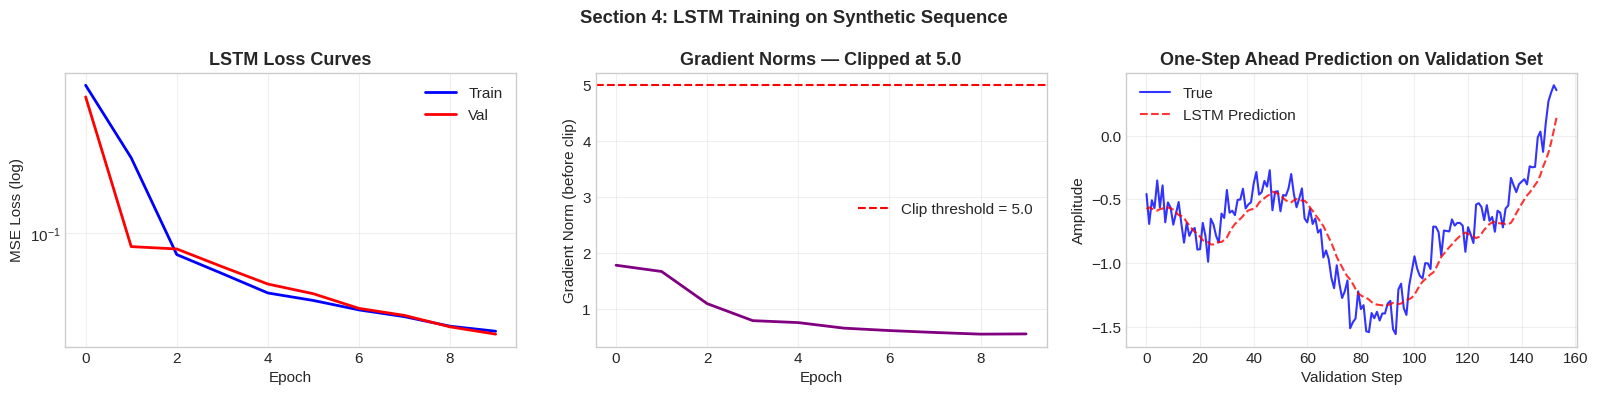


  Validation RMSE: 0.16768
  Gradient clipped in 0% of training steps
  → Clipping was inactive for this signal


In [ ]:
# ─── 4.4 RNN training loop — with gradient clipping ─────────────────────────
print("\n─── Step 4.4: Training the LSTM (with gradient clipping) ────────────────")

if TORCH_OK:
    set_seed(42)

    lstm_model = SimpleLSTM(hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
    criterion_seq = nn.MSELoss()
    opt_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)
    CLIP_GRAD_NORM = 5.0    # safe default for RNNs

    hist_lstm = {'train_loss': [], 'val_loss': [], 'grad_norm': []}

    print(f"\n🚀 Training LSTM for {N_EPOCHS_RNN} epochs (gradient clipping={CLIP_GRAD_NORM})...")

    for epoch in range(1, N_EPOCHS_RNN + 1):
        lstm_model.train()
        tr_loss, gnorm_sum, n_b = 0.0, 0.0, 0
        for X_b, y_b in dl_tr_seq:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt_lstm.zero_grad()
            pred = lstm_model(X_b)
            loss = criterion_seq(pred, y_b)
            loss.backward()

            # ── Gradient clipping (critical for RNNs) ─────────────────────────
            total_norm = nn.utils.clip_grad_norm_(lstm_model.parameters(), CLIP_GRAD_NORM)
            gnorm_sum += total_norm.item()

            opt_lstm.step()
            tr_loss += loss.item(); n_b += 1

        lstm_model.eval()
        vl, nvb = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in dl_val_seq:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vl += criterion_seq(lstm_model(X_b), y_b).item(); nvb += 1

        hist_lstm['train_loss'].append(tr_loss / n_b)
        hist_lstm['val_loss'].append(vl / nvb)
        hist_lstm['grad_norm'].append(gnorm_sum / n_b)

        if epoch % max(1, N_EPOCHS_RNN // 5) == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{N_EPOCHS_RNN}  "
                  f"train={tr_loss/n_b:.5f}  val={vl/nvb:.5f}  "
                  f"grad_norm={gnorm_sum/n_b:.3f}")

    # ── Plot loss curves + gradient norms ─────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].semilogy(hist_lstm['train_loss'], 'b-', lw=2, label='Train')
    axes[0].semilogy(hist_lstm['val_loss'],   'r-', lw=2, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss (log)')
    axes[0].set_title('LSTM Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist_lstm['grad_norm'], 'purple', lw=2)
    axes[1].axhline(CLIP_GRAD_NORM, color='red', linestyle='--', lw=1.5,
                    label=f'Clip threshold = {CLIP_GRAD_NORM}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gradient Norm (before clip)')
    axes[1].set_title(f'Gradient Norms — Clipped at {CLIP_GRAD_NORM}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # ── Prediction vs true signal ──────────────────────────────────────────────
    lstm_model.eval()
    with torch.no_grad():
        preds_val = lstm_model(X_val_st.to(DEVICE)).cpu().numpy().ravel()
    true_val = y_val_seq.ravel()

    axes[2].plot(true_val, 'b-', lw=1.5, label='True', alpha=0.8)
    axes[2].plot(preds_val, 'r--', lw=1.5, label='LSTM Prediction', alpha=0.8)
    axes[2].set_xlabel('Validation Step'); axes[2].set_ylabel('Amplitude')
    axes[2].set_title('One-Step Ahead Prediction on Validation Set')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle('Section 4: LSTM Training on Synthetic Sequence', fontweight='bold')
    plt.tight_layout(); plt.show()

    rmse_lstm = np.sqrt(np.mean((true_val - preds_val)**2))
    print(f"\n  Validation RMSE: {rmse_lstm:.5f}")
    clipped_pct = np.mean(np.array(hist_lstm['grad_norm']) > CLIP_GRAD_NORM) * 100
    print(f"  Gradient clipped in {clipped_pct:.0f}% of training steps")
    print(f"  → Clipping was {'active — important!' if clipped_pct > 0 else 'inactive for this signal'}")


─── Step 4.5: Lookback Length Sensitivity ───────────────────────────────
    L=  5: val_loss=0.03666
    L= 15: val_loss=0.04118
    L= 30: val_loss=0.03653
    L= 60: val_loss=0.03893


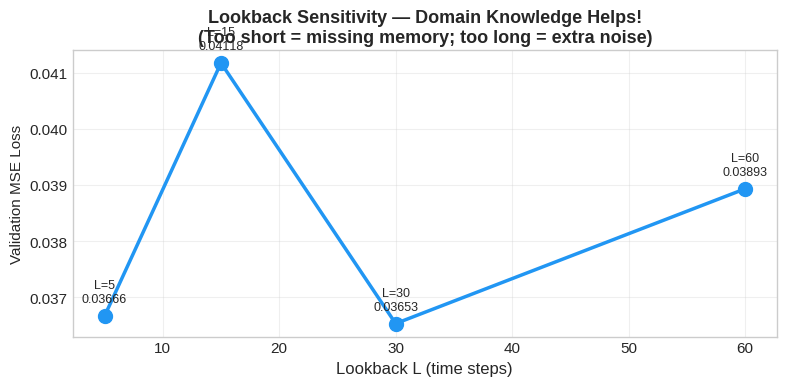


  Best lookback: L=30 (val_loss=0.03653)

💡 Lookback is a domain-informed hyperparameter:
   • Hydrology: L = 30 days (antecedent soil moisture)
   • Traffic:   L = 48 steps of 15 min = 12 hours
   • Vibration: L = duration of one vibration cycle


In [ ]:
# ─── 4.5 Lookback length experiment ─────────────────────────────────────────
print("\n─── Step 4.5: Lookback Length Sensitivity ───────────────────────────────")

if TORCH_OK:
    lookbacks = [5, 15, 30, 60]
    val_losses_by_L = {}

    for L in lookbacks:
        set_seed(42)
        Xq, yq = make_sequences(raw_signal, lookback=L)
        sp = int(0.8 * len(Xq))
        dl_tr_q = DataLoader(TensorDataset(
            torch.tensor(Xq[:sp]).unsqueeze(-1),
            torch.tensor(yq[:sp])), batch_size=32, shuffle=False)
        dl_val_q = DataLoader(TensorDataset(
            torch.tensor(Xq[sp:]).unsqueeze(-1),
            torch.tensor(yq[sp:])), batch_size=32, shuffle=False)

        m_L = SimpleLSTM(hidden_size=32, num_layers=1, dropout=0.0).to(DEVICE)
        opt_L = optim.Adam(m_L.parameters(), lr=1e-3)
        final_val = 1e9

        for ep in range(max(N_EPOCHS_RNN, 10)):
            m_L.train()
            for X_b, y_b in dl_tr_q:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                opt_L.zero_grad()
                loss_L = criterion_seq(m_L(X_b), y_b)
                loss_L.backward()
                nn.utils.clip_grad_norm_(m_L.parameters(), 5.0)
                opt_L.step()

            m_L.eval()
            vl, nvb = 0.0, 0
            with torch.no_grad():
                for X_b, y_b in dl_val_q:
                    X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                    vl += criterion_seq(m_L(X_b), y_b).item(); nvb += 1
            final_val = vl / nvb

        val_losses_by_L[L] = final_val
        print(f"    L={L:3d}: val_loss={final_val:.5f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(lookbacks, [val_losses_by_L[L] for L in lookbacks],
            'o-', color='#2196F3', lw=2.5, markersize=10)
    ax.set_xlabel('Lookback L (time steps)', fontsize=12)
    ax.set_ylabel('Validation MSE Loss')
    ax.set_title('Lookback Sensitivity — Domain Knowledge Helps!\n'
                 '(Too short = missing memory; too long = extra noise)',
                 fontweight='bold')
    for L, vl in val_losses_by_L.items():
        ax.annotate(f'L={L}\n{vl:.5f}', (L, vl), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    best_L = min(val_losses_by_L, key=val_losses_by_L.get)
    print(f"\n  Best lookback: L={best_L} (val_loss={val_losses_by_L[best_L]:.5f})")
    print(f"\n💡 Lookback is a domain-informed hyperparameter:")
    print(f"   • Hydrology: L = 30 days (antecedent soil moisture)")
    print(f"   • Traffic:   L = 48 steps of 15 min = 12 hours")
    print(f"   • Vibration: L = duration of one vibration cycle")


─── Step 4.6: Hidden State — What the LSTM 'Remembers' ─────────────────


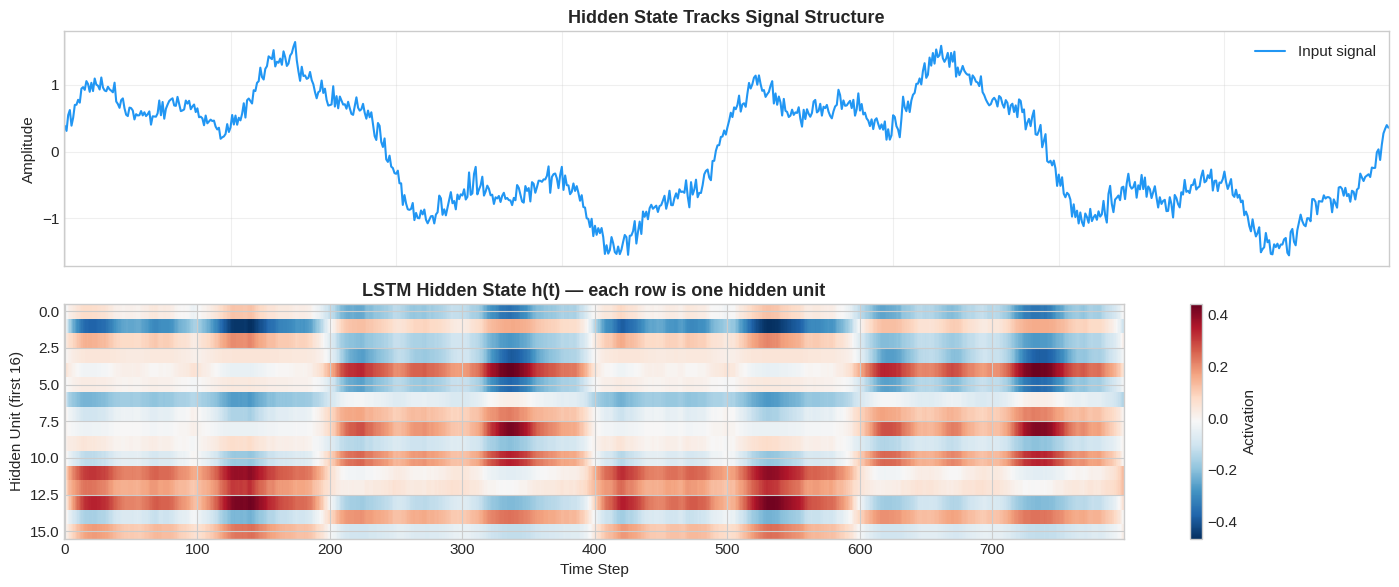


  Hidden state shape: (800, 16)  (T=800 × n_h=16 units shown)
  Notice: different hidden units activate at different signal phases.
  → The LSTM distributes temporal memory across its hidden units.


In [ ]:
# ─── 4.6 Hidden state visualisation ─────────────────────────────────────────
print("\n─── Step 4.6: Hidden State — What the LSTM 'Remembers' ─────────────────")

if TORCH_OK:
    # Run the signal through the LSTM step by step, record hidden states
    lstm_model.eval()

    # Process the whole raw signal as one long sequence
    sig_tensor = torch.tensor(raw_signal).unsqueeze(0).unsqueeze(-1).to(DEVICE)  # (1, T, 1)
    hidden_states = []

    with torch.no_grad():
        # Process step by step to capture all hidden states
        h0 = torch.zeros(2, 1, 64).to(DEVICE)
        c0 = torch.zeros(2, 1, 64).to(DEVICE)
        hid = (h0, c0)
        for t in range(sig_tensor.shape[1]):
            step_in = sig_tensor[:, t:t+1, :]
            out, hid = lstm_model.lstm(step_in, hid)
            hidden_states.append(out[0, 0, :16].cpu().numpy())  # first 16 units

    H = np.array(hidden_states)   # (T, 16)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(raw_signal, color='#2196F3', lw=1.5, label='Input signal')
    axes[0].set_ylabel('Amplitude'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Hidden State Tracks Signal Structure', fontweight='bold')

    im = axes[1].imshow(H.T, aspect='auto', cmap='RdBu_r',
                         interpolation='nearest', origin='upper')
    axes[1].set_ylabel('Hidden Unit (first 16)')
    axes[1].set_xlabel('Time Step')
    axes[1].set_title('LSTM Hidden State h(t) — each row is one hidden unit')
    plt.colorbar(im, ax=axes[1], label='Activation')
    plt.tight_layout(); plt.show()

    print(f"\n  Hidden state shape: {H.shape}  (T={n_seq_steps} × n_h=16 units shown)")
    print(f"  Notice: different hidden units activate at different signal phases.")
    print(f"  → The LSTM distributes temporal memory across its hidden units.")

In [ ]:
print("\n" + "=" * 65)
print("SECTION 4 SUMMARY: RNN Temporal Workflow")
print("=" * 65)

print("""
  ✅ Generated synthetic multi-frequency signal (sensor analogy)
  ✅ Sliding window windowing → (X_window, y_target) pairs
  ✅ Temporal train/val split — CHRONOLOGICAL, no shuffling
  ✅ SimpleLSTM (2-layer, dropout, batch_first=True) — defined inline
  ✅ Training with gradient clipping (essential for RNNs)
  ✅ Lookback sensitivity experiment (L=5,15,30,60)
  ✅ Hidden state visualisation — the LSTM's learned temporal memory

  Key differences vs FNN/CNN:
  • Data: windowing + TEMPORAL split (not random split)
  • Model: LSTM processes input one step at a time
  • Training: gradient clipping prevents NaN from exploding gradients
  • Evaluation: RMSE on time series + visual overlay
  • Hyperparameter: lookback L is domain-specific
""")


SECTION 4 SUMMARY: RNN Temporal Workflow

  ✅ Generated synthetic multi-frequency signal (sensor analogy)
  ✅ Sliding window windowing → (X_window, y_target) pairs
  ✅ Temporal train/val split — CHRONOLOGICAL, no shuffling
  ✅ SimpleLSTM (2-layer, dropout, batch_first=True) — defined inline
  ✅ Training with gradient clipping (essential for RNNs)
  ✅ Lookback sensitivity experiment (L=5,15,30,60)
  ✅ Hidden state visualisation — the LSTM's learned temporal memory

  Key differences vs FNN/CNN:
  • Data: windowing + TEMPORAL split (not random split)
  • Model: LSTM processes input one step at a time
  • Training: gradient clipping prevents NaN from exploding gradients
  • Evaluation: RMSE on time series + visual overlay
  • Hyperparameter: lookback L is domain-specific



---
## Section 5: Scratch vs Pretrained — Transfer Learning in Practice

**Question:** When does a pretrained model outperform training from scratch?

**Experiment:** Train FashionMNIST classification three ways:
1. **Scratch CNN** — our SimpleCNN from Section 3
2. **Frozen ResNet-18** — pretrained backbone, only train the final FC layer
3. **Fine-tuned ResNet-18** — pretrained backbone + fine-tune entire network

**Why this matters:**
- Civil engineering datasets are often small (hundreds to thousands of images)
- Pretrained models encode universal low-level features (edges, textures, shapes)
- These features transfer surprisingly well to structural and material images

**Note on RNN transfer learning:**
Pretrained sequence models (BERT, GPT-2) are intentionally omitted here —
they are too large for CPU teaching and better covered in Lecture 13 (Transformers).
The concept is identical: pre-train on large corpus, fine-tune the final layers.

SECTION 5: SCRATCH vs PRETRAINED — TRANSFER LEARNING

📊 Benchmark: Scratch SimpleCNN test acc = 86.0%
   (Trained on 5000 FashionMNIST images, 5 epochs)

📥 Loading ResNet-18 pretrained on ImageNet...
   FashionMNIST adapted: 1×28×28 → 3×64×64 (grayscale repeated + resize)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


   ✅ ResNet-18 loaded (11,689,512 params)

─── 5.3 Frozen Backbone Run ─────────────────────────────────────────
   Trainable params: 5,130 / 11,181,642 (0.0%) — only the final FC layer!
  Epoch   1/5  train_loss=1.3789  val_loss=0.9224  train_acc=0.559  val_acc=0.720
  Epoch   2/5  train_loss=0.8174  val_loss=0.8073  train_acc=0.735  val_acc=0.739
  Epoch   3/5  train_loss=0.7116  val_loss=0.7360  train_acc=0.765  val_acc=0.759
  Epoch   4/5  train_loss=0.6351  val_loss=0.7022  train_acc=0.788  val_acc=0.770
  Epoch   5/5  train_loss=0.6072  val_loss=0.6965  train_acc=0.802  val_acc=0.770

─── 5.4 Fine-Tuned ResNet Run ───────────────────────────────────────
   Trainable params: 11,181,642 — entire network!
  Epoch   1/5  train_loss=0.6403  val_loss=0.3883  train_acc=0.782  val_acc=0.865
  Epoch   2/5  train_loss=0.2285  val_loss=0.3671  train_acc=0.922  val_acc=0.878
  Epoch   3/5  train_loss=0.1410  val_loss=0.3858  train_acc=0.953  val_acc=0.882
  Epoch   4/5  train_loss=0.0869  va

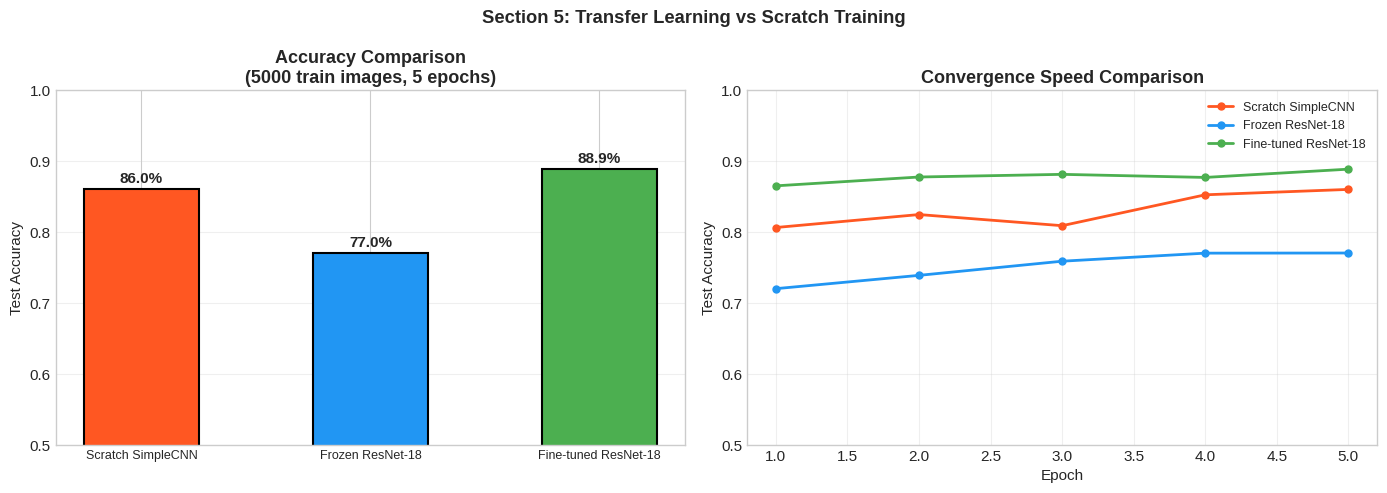


💡 Key Takeaways:
   • Frozen ResNet can be surprisingly good even with just 1 layer retrained
     → Pretrained features (edges, textures) transfer across domains
   • Fine-tuned ResNet (lower LR!) often gives best final accuracy
   • For small CE datasets (<5k images): always try transfer learning first

   On RNN transfer learning:
   → Same concept: pretrain LSTM on large time-series corpus,
     fine-tune on specific CE task (e.g., your streamflow gauge)
   → Transformers (Lecture 13) have largely replaced recurrent TL models


In [ ]:
print("=" * 65)
print("SECTION 5: SCRATCH vs PRETRAINED — TRANSFER LEARNING")
print("=" * 65)

if TV_DATA_OK and TORCH_OK:
    # ── 5.1 Scratch CNN (reuse from Section 3) ────────────────────────────────
    scratch_acc = hist_cnn['val_acc'][-1]
    print(f"\n📊 Benchmark: Scratch SimpleCNN test acc = {scratch_acc:.1%}")
    print(f"   (Trained on {DATA_SUBSET} FashionMNIST images, {N_EPOCHS_CNN} epochs)")

    # ── 5.2 Prepare FashionMNIST for ResNet (needs 3-channel 224×224) ─────────
    print(f"\n📥 Loading ResNet-18 pretrained on ImageNet...")

    # FashionMNIST = 1-channel 28×28. ResNet expects 3-channel ≥ 64×64.
    # We adapt via a simple 3-channel repeat + resize.
    transform_resnet = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),  # 1→3 channels by repeat
        transforms.Resize((64, 64)),                  # upsample from 28 to 64
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),  # ImageNet stats
    ])

    ds_rn_train = Subset(
        FashionMNIST('/tmp/fmnist', train=True, download=False,
                     transform=transform_resnet),
        indices
    )
    ds_rn_test = FashionMNIST('/tmp/fmnist', train=False, download=False,
                               transform=transform_resnet)

    dl_rn_train = DataLoader(ds_rn_train, batch_size=64, shuffle=True,  num_workers=0)
    dl_rn_test  = DataLoader(ds_rn_test,  batch_size=128, shuffle=False, num_workers=0)

    print(f"   FashionMNIST adapted: 1×28×28 → 3×64×64 (grayscale repeated + resize)")

    # Load ResNet-18
    try:
        from torchvision.models import resnet18, ResNet18_Weights
        rn18_pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
        print(f"   ✅ ResNet-18 loaded ({sum(p.numel() for p in rn18_pretrained.parameters()):,} params)")
        RN_OK = True
    except Exception as e:
        print(f"   ⚠️ ResNet-18 download failed: {e}")
        print("   Falling back to randomly initialised ResNet-18 for structure demo.")
        rn18_pretrained = tv_models.resnet18(weights=None)
        RN_OK = False

    def build_resnet_for_fmnist(pretrained_model, freeze_backbone: bool):
        """Modify ResNet-18 for FashionMNIST (10 classes)."""
        model = copy.deepcopy(pretrained_model)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        # Replace final FC layer (1000 → 10)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 10)  # always trainable
        return model

    # ── 5.3 Frozen backbone (only train final FC) ──────────────────────────────
    print(f"\n─── 5.3 Frozen Backbone Run ─────────────────────────────────────────")
    set_seed(42)
    rn_frozen = build_resnet_for_fmnist(rn18_pretrained, freeze_backbone=True).to(DEVICE)
    frozen_trainable = sum(p.numel() for p in rn_frozen.parameters() if p.requires_grad)
    total_rn = sum(p.numel() for p in rn_frozen.parameters())
    print(f"   Trainable params: {frozen_trainable:,} / {total_rn:,} "
          f"({frozen_trainable/total_rn*100:.1f}%) — only the final FC layer!")

    opt_frozen = optim.Adam(filter(lambda p: p.requires_grad, rn_frozen.parameters()),
                              lr=1e-3)
    hist_frozen = train_loop(rn_frozen, dl_rn_train, dl_rn_test,
                              opt_frozen, nn.CrossEntropyLoss(),
                              n_epochs=N_EPOCHS_CNN, verbose=True)

    # ── 5.4 Fine-tuned (unfreeze all layers) ────────────────────────────────────
    print(f"\n─── 5.4 Fine-Tuned ResNet Run ───────────────────────────────────────")
    set_seed(42)
    rn_finetune = build_resnet_for_fmnist(rn18_pretrained, freeze_backbone=False).to(DEVICE)
    print(f"   Trainable params: {count_params(rn_finetune):,} — entire network!")

    # Use smaller LR for fine-tuning (avoid overwriting pretrained features)
    opt_finetune = optim.Adam(rn_finetune.parameters(), lr=1e-4, weight_decay=1e-4)
    hist_finetune = train_loop(rn_finetune, dl_rn_train, dl_rn_test,
                                opt_finetune, nn.CrossEntropyLoss(),
                                n_epochs=N_EPOCHS_CNN, verbose=True)

    # ── 5.5 Fair comparison ───────────────────────────────────────────────────
    print(f"\n─── 5.5 Comparison ──────────────────────────────────────────────────")

    results_tl = {
        'Scratch SimpleCNN':    (scratch_acc,                     count_params(SimpleCNN().to(DEVICE))),
        'Frozen ResNet-18':     (hist_frozen['val_acc'][-1],       frozen_trainable),
        'Fine-tuned ResNet-18': (hist_finetune['val_acc'][-1],    count_params(rn_finetune)),
    }

    print(f"\n  {'Method':<25} {'Test Acc':>10}  {'Trainable Params':>18}")
    print(f"  {'-'*60}")
    for method, (acc, params) in results_tl.items():
        print(f"  {method:<25} {acc:>9.1%}  {params:>18,}")

    # Bar + convergence plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    labels_tl = list(results_tl.keys())
    accs_tl   = [v[0] for v in results_tl.values()]
    bars = axes[0].bar(labels_tl, accs_tl,
                        color=['#FF5722', '#2196F3', '#4CAF50'], width=0.5,
                        edgecolor='black', linewidth=1.5)
    axes[0].set_ylim(0.5, 1.0)
    axes[0].set_ylabel('Test Accuracy')
    axes[0].set_title(f'Accuracy Comparison\n({DATA_SUBSET} train images, {N_EPOCHS_CNN} epochs)')
    for bar, acc in zip(bars, accs_tl):
        axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.005,
                    f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', labelsize=9)

    epochs_tl = range(1, N_EPOCHS_CNN + 1)
    for hist, label, col in [
        (hist_cnn,      'Scratch SimpleCNN',    '#FF5722'),
        (hist_frozen,   'Frozen ResNet-18',      '#2196F3'),
        (hist_finetune, 'Fine-tuned ResNet-18',  '#4CAF50'),
    ]:
        axes[1].plot(epochs_tl, hist['val_acc'], '-o', color=col,
                    lw=2, markersize=5, label=label)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title('Convergence Speed Comparison')
    axes[1].legend(fontsize=9); axes[1].set_ylim(0.5, 1.0)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Section 5: Transfer Learning vs Scratch Training', fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"\n💡 Key Takeaways:")
    print(f"   • Frozen ResNet can be surprisingly good even with just 1 layer retrained")
    print(f"     → Pretrained features (edges, textures) transfer across domains")
    print(f"   • Fine-tuned ResNet (lower LR!) often gives best final accuracy")
    print(f"   • For small CE datasets (<5k images): always try transfer learning first")
    print(f"\n   On RNN transfer learning:")
    print(f"   → Same concept: pretrain LSTM on large time-series corpus,")
    print(f"     fine-tune on specific CE task (e.g., your streamflow gauge)")
    print(f"   → Transformers (Lecture 13) have largely replaced recurrent TL models")

elif not TV_DATA_OK:
    print("⚠️ FashionMNIST not available — skipping Section 5 (requires torchvision)")
    print("   The key insight: pretrained ResNet typically outperforms scratch CNN by 5–15%")
    print("   on small datasets, with faster convergence and fewer trainable parameters.")

---
## Section 6: Failure Modes, Diagnostics, and Debugging

Training always breaks at some point. This section gives you the tools to recognise
*why* training failed and how to fix it.

### The Six Failure Modes We Cover

| # | Failure | Symptom | Fix |
|---|---|---|---|
| 6-A | LR too high | Loss diverges / oscillates | Reduce LR; use Adam |
| 6-B | Vanishing gradients | Near-zero gradient norms | ReLU + He init + BatchNorm |
| 6-C | Exploding gradients (RNN) | NaN loss | Gradient clipping |
| 6-D | Memorising noise | 100% train acc, ~chance val acc | More data; regularise; dropout |
| 6-E | Class imbalance | High accuracy but zero recall on minority | Weighted CrossEntropy |
| 6-F | BatchNorm impact | Unstable training with deep nets | Enable BatchNorm |

SECTION 6: FAILURE MODES, DIAGNOSTICS & DEBUGGING

🔴 6-A: Learning Rate Too High → Divergence
🔴 6-B: Vanishing Gradients → Deep Sigmoid Network
   Sigmoid final grad: 2.30e-01
   ReLU final grad:    5.39e-01
🔴 6-C: Exploding Gradients in RNN → NaN without Clipping
🔴 6-D: Memorising Noise → 100% Train, ~10% Val
🟡 6-E: Class Imbalance — Accuracy Trap
  Note: No-weighting acc ≈ 95% (predicts majority always!)
  Weighted CE forces learning minority class at cost of overall acc.
🟢 6-F: BatchNorm Stabilises Deep Networks


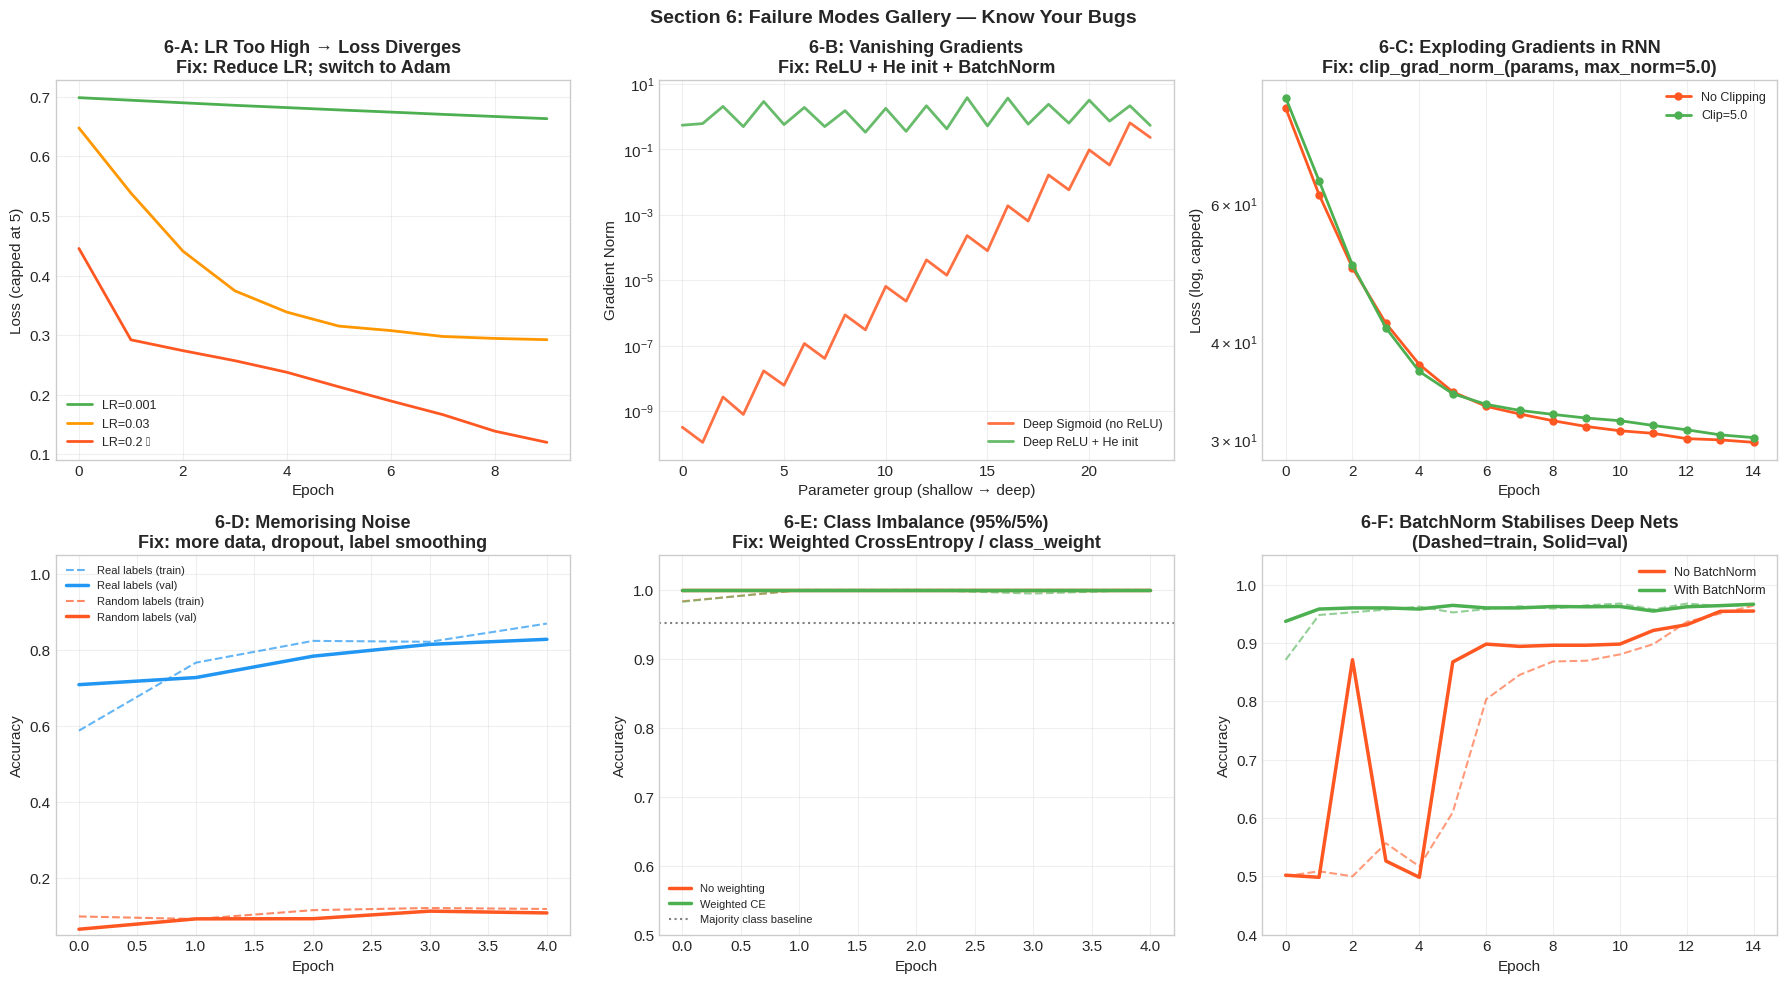

In [ ]:
print("=" * 65)
print("SECTION 6: FAILURE MODES, DIAGNOSTICS & DEBUGGING")
print("=" * 65)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 6-A: LR too high ─────────────────────────────────────────────────────────
print("\n🔴 6-A: Learning Rate Too High → Divergence")

if TORCH_OK:
    lrs_6a = [1e-3, 3e-2, 2e-1]
    colors_6a = ['#4CAF50', '#FF9800', '#FF5722']
    for lr_6a, col in zip(lrs_6a, colors_6a):
        set_seed(42)
        m6a = MoonsFNN(hidden=32).to(DEVICE)
        h6a = train_loop(m6a, dl_tr_m, dl_val_m,
                          optim.SGD(m6a.parameters(), lr=lr_6a),
                          nn.CrossEntropyLoss(), n_epochs=max(N_EPOCHS_DEMO*2, 10),
                          verbose=False)
        clipped = [min(l, 5.0) for l in h6a['train_loss']]
        axes[0,0].plot(clipped, '-', color=col, lw=2,
                       label=f'LR={lr_6a}' + (' 🚨' if lr_6a >= 0.1 else ''))

    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss (capped at 5)')
    axes[0,0].set_title('6-A: LR Too High → Loss Diverges\n'
                         'Fix: Reduce LR; switch to Adam', fontweight='bold')
    axes[0,0].legend(fontsize=9); axes[0,0].grid(True, alpha=0.3)

# ── 6-B: Vanishing gradients ─────────────────────────────────────────────────
print("🔴 6-B: Vanishing Gradients → Deep Sigmoid Network")

if TORCH_OK:
    # Deep sigmoid network — gradients vanish through many tanh layers
    class DeepSigmoid(nn.Module):
        def __init__(self, n_layers=10):
            super().__init__()
            layers = []
            for i in range(n_layers):
                layers += [nn.Linear(32, 32), nn.Sigmoid()]
            layers.append(nn.Linear(32, 2))
            # Use Glorot init (bad for very deep sigmoid)
            self.net = nn.Sequential(nn.Linear(2, 32), nn.Sigmoid(), *layers)
        def forward(self, x): return self.net(x)

    class DeepReLU(nn.Module):
        def __init__(self, n_layers=10):
            super().__init__()
            layers = []
            for i in range(n_layers):
                layers += [nn.Linear(32, 32), nn.ReLU()]
            layers.append(nn.Linear(32, 2))
            self.net = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), *layers)
            # He init
            for m in self.net:
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        def forward(self, x): return self.net(x)

    grad_norms_by_depth = {}
    for Name, ModelClass in [('Deep Sigmoid (no ReLU)', DeepSigmoid),
                              ('Deep ReLU + He init',   DeepReLU)]:
        set_seed(42)
        m6b = ModelClass().to(DEVICE)
        opt_6b = optim.SGD(m6b.parameters(), lr=0.01)
        m6b.train()
        X_b6, y_b6 = next(iter(dl_tr_m))
        X_b6, y_b6 = X_b6.to(DEVICE), y_b6.to(DEVICE)
        opt_6b.zero_grad()
        nn.CrossEntropyLoss()(m6b(X_b6), y_b6).backward()
        norms = [p.grad.norm().item() for p in m6b.parameters()
                 if p.requires_grad and p.grad is not None]
        grad_norms_by_depth[Name] = norms

    colors_6b = ['#FF5722', '#4CAF50']
    for (name, norms), col in zip(grad_norms_by_depth.items(), colors_6b):
        axes[0,1].plot(range(len(norms)), norms, '-', color=col, lw=2, label=name, alpha=0.85)

    axes[0,1].set_xlabel('Parameter group (shallow → deep)')
    axes[0,1].set_ylabel('Gradient Norm')
    axes[0,1].set_yscale('log')
    axes[0,1].set_title('6-B: Vanishing Gradients\n'
                         'Fix: ReLU + He init + BatchNorm', fontweight='bold')
    axes[0,1].legend(fontsize=9); axes[0,1].grid(True, alpha=0.3)

    print(f"   Sigmoid final grad: {grad_norms_by_depth['Deep Sigmoid (no ReLU)'][-1]:.2e}")
    print(f"   ReLU final grad:    {grad_norms_by_depth['Deep ReLU + He init'][-1]:.2e}")

# ── 6-C: Exploding gradients (RNN without clipping) ──────────────────────────
print("🔴 6-C: Exploding Gradients in RNN → NaN without Clipping")

if TORCH_OK:
    set_seed(42)
    m6c_noclip = SimpleLSTM(hidden_size=64, num_layers=2, dropout=0.0).to(DEVICE)
    m6c_clip   = SimpleLSTM(hidden_size=64, num_layers=2, dropout=0.0).to(DEVICE)

    # Use a difficult signal (high amplitude noise)
    noisy_sig = raw_signal * 10 + np.random.randn(n_seq_steps).astype(np.float32) * 5
    Xn, yn = make_sequences(noisy_sig, lookback=LOOKBACK)
    sp_n = int(0.8 * len(Xn))
    dl_noisy = DataLoader(TensorDataset(
        torch.tensor(Xn[:sp_n]).unsqueeze(-1),
        torch.tensor(yn[:sp_n])), batch_size=32, shuffle=False)

    losses_by_clip = {'No Clipping': [], 'Clip=5.0': []}
    for m6c, clip_val, key in [(m6c_noclip, None, 'No Clipping'),
                                (m6c_clip, 5.0, 'Clip=5.0')]:
        opt_6c = optim.Adam(m6c.parameters(), lr=1e-3)
        for _ in range(15):
            m6c.train(); ep_loss = 0.0; nb = 0
            for X_b, y_b in dl_noisy:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                opt_6c.zero_grad()
                loss6c = criterion_seq(m6c(X_b), y_b)
                loss6c.backward()
                if clip_val: nn.utils.clip_grad_norm_(m6c.parameters(), clip_val)
                opt_6c.step()
                ep_loss += loss6c.item() if not math.isnan(loss6c.item()) else 1e6; nb += 1
            losses_by_clip[key].append(ep_loss / nb)

    for (key, losses), col in zip(losses_by_clip.items(), ['#FF5722', '#4CAF50']):
        safe = [min(l, 1e4) for l in losses]
        axes[0,2].semilogy(safe, '-o', color=col, lw=2, markersize=5, label=key)
    axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Loss (log, capped)')
    axes[0,2].set_title('6-C: Exploding Gradients in RNN\n'
                         'Fix: clip_grad_norm_(params, max_norm=5.0)', fontweight='bold')
    axes[0,2].legend(fontsize=9); axes[0,2].grid(True, alpha=0.3)

# ── 6-D: Memorising random labels ────────────────────────────────────────────
print("🔴 6-D: Memorising Noise → 100% Train, ~10% Val")

if TORCH_OK:
    set_seed(42)
    n_noise = min(DATA_SUBSET // 4, 2000)
    # Take first n_noise samples, shuffle their labels randomly
    noise_imgs = [ds_fmnist_train_full[i][0] for i in range(n_noise)] if TV_DATA_OK else \
                 [torch.randn(1, 28, 28) for _ in range(n_noise)]
    noise_labels_true = [ds_fmnist_train_full[i][1] for i in range(n_noise)] if TV_DATA_OK else \
                        [0] * n_noise
    noise_labels_rand = torch.randint(0, 10, (n_noise,)).long()
    noise_labels_true_t = torch.tensor(noise_labels_true).long()

    def quick_cnn_train(imgs, labels, n_epochs=max(N_EPOCHS_CNN, 5)):
        m = SimpleCNN(n_classes=10).to(DEVICE)
        ds = TensorDataset(torch.stack(imgs), labels)
        dl_tr_n = DataLoader(Subset(ds, range(int(0.8*len(ds)))), batch_size=64, shuffle=True)
        dl_val_n = DataLoader(Subset(ds, range(int(0.8*len(ds)), len(ds))), batch_size=64)
        opt = optim.Adam(m.parameters(), lr=1e-3)
        h = train_loop(m, dl_tr_n, dl_val_n, opt, nn.CrossEntropyLoss(),
                       n_epochs=n_epochs, verbose=False)
        return h

    hist_real   = quick_cnn_train(noise_imgs, noise_labels_true_t)
    hist_random = quick_cnn_train(noise_imgs, noise_labels_rand)

    for (h, lbl, col) in [(hist_real, 'Real labels (train)', '#2196F3'),
                           (hist_random, 'Random labels (train)', '#FF5722')]:
        axes[1,0].plot(h['train_acc'], '--', color=col, lw=1.5, alpha=0.7, label=f'{lbl}')
        axes[1,0].plot(h['val_acc'],   '-',  color=col, lw=2.5,
                       label=lbl.replace('train', 'val'))

    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy')
    axes[1,0].set_ylim(0.05, 1.05)
    axes[1,0].set_title('6-D: Memorising Noise\n'
                         'Fix: more data, dropout, label smoothing', fontweight='bold')
    axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)

# ── 6-E: Class imbalance ──────────────────────────────────────────────────────
print("🟡 6-E: Class Imbalance — Accuracy Trap")

if TORCH_OK and TV_DATA_OK:
    # Create imbalanced FashionMNIST: 95% T-shirts (class 0), 5% everything else → class 1 (boot)
    all_idx = list(range(len(ds_fmnist_train_full)))
    cls0_idx = [i for i, (_, l) in enumerate(ds_fmnist_train_full) if l == 0][:2000]
    cls1_idx = [i for i, (_, l) in enumerate(ds_fmnist_train_full) if l == 9][:100]
    imb_idx  = cls0_idx + cls1_idx

    import random; random.shuffle(imb_idx)

    def make_binary_label(label_orig, pos_class=9):
        return 1 if label_orig == pos_class else 0

    imb_imgs   = [ds_fmnist_train_full[i][0] for i in imb_idx]
    imb_labels = torch.tensor([make_binary_label(ds_fmnist_train_full[i][1]) for i in imb_idx])

    split_imb = int(0.8 * len(imb_idx))
    dl_imb_tr  = DataLoader(TensorDataset(torch.stack(imb_imgs[:split_imb]),
                                           imb_labels[:split_imb]),
                             batch_size=32, shuffle=True)
    dl_imb_val = DataLoader(TensorDataset(torch.stack(imb_imgs[split_imb:]),
                                           imb_labels[split_imb:]),
                             batch_size=32, shuffle=False)

    class BinaryCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.base = SimpleCNN(n_classes=2, dropout=0.2)
        def forward(self, x): return self.base(x)

    histories_imb = {}
    n_ep_imb = max(N_EPOCHS_CNN, 5)

    for (label_imb, weight_tensor) in [
        ('No weighting',     None),
        ('Weighted CE',      torch.tensor([1.0, 20.0]).to(DEVICE)),  # 20× weight for minority
    ]:
        set_seed(42)
        m_imb = BinaryCNN().to(DEVICE)
        crit_imb = nn.CrossEntropyLoss(weight=weight_tensor)
        hist_imb = train_loop(m_imb, dl_imb_tr, dl_imb_val,
                               optim.Adam(m_imb.parameters(), lr=1e-3), crit_imb,
                               n_epochs=n_ep_imb, verbose=False)
        histories_imb[label_imb] = hist_imb

    colors_imb = ['#FF5722', '#4CAF50']
    for (lbl, h), col in zip(histories_imb.items(), colors_imb):
        axes[1,1].plot(h['train_acc'], '--', color=col, lw=1.5, alpha=0.6)
        axes[1,1].plot(h['val_acc'],   '-',  color=col, lw=2.5, label=lbl)

    axes[1,1].axhline(2000/(2000+100), color='gray', linestyle=':', lw=1.5,
                       label='Majority class baseline')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy')
    axes[1,1].set_ylim(0.5, 1.05)
    axes[1,1].set_title('6-E: Class Imbalance (95%/5%)\n'
                         'Fix: Weighted CrossEntropy / class_weight', fontweight='bold')
    axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)

    print(f"  Note: No-weighting acc ≈ 95% (predicts majority always!)")
    print(f"  Weighted CE forces learning minority class at cost of overall acc.")

# ── 6-F: BatchNorm impact on deep networks ──────────────────────────────────
print("🟢 6-F: BatchNorm Stabilises Deep Networks")

if TORCH_OK:
    class DeepFNN(nn.Module):
        def __init__(self, use_bn=False, n_hidden=6):
            super().__init__()
            layers = [nn.Linear(2, 64)]
            for _ in range(n_hidden):
                if use_bn: layers.append(nn.BatchNorm1d(64))
                layers += [nn.ReLU(), nn.Linear(64, 64)]
            layers.append(nn.Linear(64, 2))
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x)

    hist_no_bn, hist_with_bn = {}, {}
    for use_bn, hist_ref, col, lbl in [(False, hist_no_bn, '#FF5722', 'No BatchNorm'),
                                        (True,  hist_with_bn, '#4CAF50', 'With BatchNorm')]:
        set_seed(42)
        m6f = DeepFNN(use_bn=use_bn).to(DEVICE)
        opt_6f = optim.SGD(m6f.parameters(), lr=0.01, momentum=0.9)
        h6f = train_loop(m6f, dl_tr_m, dl_val_m, opt_6f, nn.CrossEntropyLoss(),
                          n_epochs=max(N_EPOCHS_DEMO*3, 15), verbose=False)
        axes[1,2].plot(h6f['val_acc'], '-', color=col, lw=2.5, label=lbl)
        axes[1,2].plot(h6f['train_acc'], '--', color=col, lw=1.5, alpha=0.6)

    axes[1,2].set_xlabel('Epoch'); axes[1,2].set_ylabel('Accuracy')
    axes[1,2].set_title('6-F: BatchNorm Stabilises Deep Nets\n'
                         '(Dashed=train, Solid=val)', fontweight='bold')
    axes[1,2].legend(fontsize=9); axes[1,2].set_ylim(0.4, 1.05)
    axes[1,2].grid(True, alpha=0.3)

plt.suptitle('Section 6: Failure Modes Gallery — Know Your Bugs',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── Summary table ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SECTION 6 SUMMARY: Failure Mode Cheat Sheet")
print("=" * 70)

failure_table = [
    ("6-A  LR too high",
     "Loss oscillates / diverges",
     "Reduce LR by 10×; switch from SGD to Adam"),
    ("6-B  Vanishing grads",
     "Near-zero grad norms in early layers",
     "ReLU activation + He init + BatchNorm"),
    ("6-C  Exploding grads (RNN)",
     "NaN loss after a few steps",
     "clip_grad_norm_(params, max_norm=5.0)"),
    ("6-D  Memorising noise",
     "Train→100%, Val→chance",
     "More data, Dropout, label smoothing"),
    ("6-E  Class imbalance",
     "High accuracy but zero recall for rare class",
     "CrossEntropyLoss(weight=...) or oversampling"),
    ("6-F  No BatchNorm (deep)",
     "Unstable training, slow convergence",
     "Add nn.BatchNorm1d/2d after each linear/conv"),
]

print(f"\n  {'Failure':<28} {'Symptom':<35} {'Fix'}")
print(f"  {'-'*95}")
for f, s, fix in failure_table:
    print(f"  {f:<28} {s:<35} {fix}")

print("\n🔑 Diagnostic workflow:")
print("   1. Plot train vs val loss curves every run")
print("   2. If train↓ val↑ → overfitting → regularise")
print("   3. If train↓↓ → spike or NaN → exploding grads → clip")
print("   4. If train barely moves → vanishing grads or LR too small")
print("   5. If accuracy high but F1 low → class imbalance → weight loss")


SECTION 6 SUMMARY: Failure Mode Cheat Sheet

  Failure                      Symptom                             Fix
  -----------------------------------------------------------------------------------------------
  6-A  LR too high             Loss oscillates / diverges          Reduce LR by 10×; switch from SGD to Adam
  6-B  Vanishing grads         Near-zero grad norms in early layers ReLU activation + He init + BatchNorm
  6-C  Exploding grads (RNN)   NaN loss after a few steps          clip_grad_norm_(params, max_norm=5.0)
  6-D  Memorising noise        Train→100%, Val→chance              More data, Dropout, label smoothing
  6-E  Class imbalance         High accuracy but zero recall for rare class CrossEntropyLoss(weight=...) or oversampling
  6-F  No BatchNorm (deep)     Unstable training, slow convergence Add nn.BatchNorm1d/2d after each linear/conv

🔑 Diagnostic workflow:
   1. Plot train vs val loss curves every run
   2. If train↓ val↑ → overfitting → regularise
   3. If tr

---
## Section 7: Summary, Cheat Sheet, and Exercises

This section consolidates everything you have learned across Sections 1–6
into a decision checklist and suggested exercises.

In [ ]:
print("=" * 70)
print("SECTION 7: SUMMARY — DEEP LEARNING TRAINING CHEAT SHEET")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  DATA PIPELINE                                                           │
│  Tabular:   StandardScaler (fit on train only!) → TensorDataset          │
│  Images:    transforms.Normalize(mean, std) → DataLoader(shuffle=True)   │
│  Sequences: sliding window → temporal split → no shuffle                 │
│  Golden rule: NEVER let validation statistics influence training data     │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  MODEL DESIGN                                                            │
│  FNN:  input → [Linear → ReLU → Dropout]×N → Linear                    │
│  CNN:  [Conv → BN → ReLU → Pool]×M → Flatten → FC                      │
│  LSTM: LSTM(input, hidden, num_layers) → fc(hidden → output)            │
│  Init: He normal for ReLU; Xavier/Glorot for Sigmoid/Tanh               │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  TRAINING LOOP (universal 4 steps)                                       │
│  model.train()                                                           │
│  optimizer.zero_grad()                                                   │
│  loss = criterion(model(X), y)                                           │
│  loss.backward()                                                         │
│  [clip_grad_norm_(params, 5.0) for RNNs only]                           │
│  optimizer.step()                                                        │
│                                                                          │
│  model.eval() + torch.no_grad() for validation                          │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  HYPERPARAMETER STARTING POINTS                                          │
│  Optimizer:    Adam(lr=1e-3, weight_decay=1e-4)                         │
│  Batch size:   64–256 (images); 32 (sequences)                          │
│  LR schedule:  CosineAnnealingLR or ReduceLROnPlateau                   │
│  Dropout:      0.2–0.4 (hidden layers); 0 on recurrent connections      │
│  Grad clip:    5.0 for RNNs; not needed for FNN/CNN (usually)           │
│  Early stop:   patience=10 on val loss; restore best weights            │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  WHEN TO USE WHICH ARCHITECTURE?                                         │
│  FNN:    Tabular features, no spatial/temporal order                    │
│  1D-CNN: Short local patterns in time (event detection)                 │
│  LSTM:   Long-range temporal dependencies (forecasting, monitoring)     │
│  BiLSTM: Offline classification of full sequences (post-event SHM)      │
│  CNN:    Spatial structure — images, spectrograms, grids                 │
│  ResNet: Image tasks with small datasets — always try transfer first    │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  DIAGNOSTIC CHECKLIST (run for every experiment)                         │
│  □ Plot train vs val loss curves                                         │
│  □ Check gradient norms per layer (should be 1e-4 – 10)                │
│  □ Compute per-class accuracy (not just overall)                        │
│  □ Residual plot for regression (should be centred at 0)                │
│  □ Confirm model is in eval() mode during validation                    │
│  □ Confirm scaler was fit on training set only                          │
└─────────────────────────────────────────────────────────────────────────┘
""")

SECTION 7: SUMMARY — DEEP LEARNING TRAINING CHEAT SHEET

┌─────────────────────────────────────────────────────────────────────────┐
│  DATA PIPELINE                                                           │
│  Tabular:   StandardScaler (fit on train only!) → TensorDataset          │
│  Images:    transforms.Normalize(mean, std) → DataLoader(shuffle=True)   │
│  Sequences: sliding window → temporal split → no shuffle                 │
│  Golden rule: NEVER let validation statistics influence training data     │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  MODEL DESIGN                                                            │
│  FNN:  input → [Linear → ReLU → Dropout]×N → Linear                    │
│  CNN:  [Conv → BN → ReLU → Pool]×M → Flatten → FC                      │
│  LSTM: LSTM(input, hidden, num_layers) → fc(hidden → output)            │
│  Init: He normal for Re

In [ ]:
# ─── Architecture decision tree ──────────────────────────────────────────────
print("=" * 70)
print("ARCHITECTURE DECISION TREE")
print("=" * 70)

print("""
    Is the input ordered (temporal/sequential)?
        ↓ No → Is the input spatial (image)?
        │           ↓ No  → FNN (tabular)
        │           ↓ Yes → CNN (or ResNet if small dataset → transfer learning)
        ↓ Yes
    Do you need real-time / streaming predictions?
        ↓ No  → Is the full sequence available at inference time?
        │           ↓ Yes → BiLSTM (both directions)
        ↓ Yes
    How long are the dependencies?
        ↓ Short (< 10 steps) → 1D-CNN (faster, local patterns)
        ↓ Long  (> 10 steps) → LSTM or GRU
    How many steps ahead to forecast?
        ↓ 1   → SimpleLSTM (many-to-one)
        ↓ > 1 → Seq2Seq LSTM (encoder-decoder)
""")

ARCHITECTURE DECISION TREE

    Is the input ordered (temporal/sequential)?
        ↓ No → Is the input spatial (image)?
        │           ↓ No  → FNN (tabular)
        │           ↓ Yes → CNN (or ResNet if small dataset → transfer learning)
        ↓ Yes
    Do you need real-time / streaming predictions?
        ↓ No  → Is the full sequence available at inference time?
        │           ↓ Yes → BiLSTM (both directions)
        ↓ Yes
    How long are the dependencies?
        ↓ Short (< 10 steps) → 1D-CNN (faster, local patterns)
        ↓ Long  (> 10 steps) → LSTM or GRU
    How many steps ahead to forecast?
        ↓ 1   → SimpleLSTM (many-to-one)
        ↓ > 1 → Seq2Seq LSTM (encoder-decoder)



In [ ]:
# ─── Suggested Exercises ──────────────────────────────────────────────────────
print("=" * 70)
print("EXERCISES")
print("=" * 70)

exercises = [
    ("Exercise 1 (FNN)",
     "Add a ReduceLROnPlateau scheduler to the beam deflection training loop.\n"
     "   Compare val loss convergence vs fixed LR=1e-3. What patience value works best?"),

    ("Exercise 2 (CNN)",
     "Modify SimpleCNN to use GlobalAveragePooling (nn.AdaptiveAvgPool2d(1))\n"
     "   instead of the Flatten → FC path. Compare parameter count and test accuracy."),

    ("Exercise 3 (RNN)",
     "Replace the SimpleLSTM with a SimpleGRU (nn.GRU with same hyperparameters).\n"
     "   Compare val RMSE and training time. Are they similar? When would LSTM be better?"),

    ("Exercise 4 (Transfer)",
     "Repeat Section 5 with only 500 FashionMNIST training images.\n"
     "   Does the gap between scratch CNN and pretrained ResNet widen? Why?"),

    ("Exercise 5 (Diagnostics)",
     "Take the vanishing gradient example (6-B) and add BatchNorm after each ReLU.\n"
     "   Does this fix the gradient norms in early layers? Plot the result."),

    ("Exercise 6 (Full pipeline)",
     "Adapt the FNN beam deflection pipeline to predict concrete compressive strength.\n"
     "   Features: [cement, water, fly_ash, superplasticiser, age]. Generate synthetic data\n"
     "   with physics: f'c ≈ A·(c/w)^n + B·ln(t), where c/w is water-cement ratio.\n"
     "   Report RMSE and R². What does the residual plot tell you?"),
]

for ex_name, ex_desc in exercises:
    print(f"\n  📝 {ex_name}:")
    print(f"     {ex_desc}")

EXERCISES

  📝 Exercise 1 (FNN):
     Add a ReduceLROnPlateau scheduler to the beam deflection training loop.
   Compare val loss convergence vs fixed LR=1e-3. What patience value works best?

  📝 Exercise 2 (CNN):
     Modify SimpleCNN to use GlobalAveragePooling (nn.AdaptiveAvgPool2d(1))
   instead of the Flatten → FC path. Compare parameter count and test accuracy.

  📝 Exercise 3 (RNN):
     Replace the SimpleLSTM with a SimpleGRU (nn.GRU with same hyperparameters).
   Compare val RMSE and training time. Are they similar? When would LSTM be better?

  📝 Exercise 4 (Transfer):
     Repeat Section 5 with only 500 FashionMNIST training images.
   Does the gap between scratch CNN and pretrained ResNet widen? Why?

  📝 Exercise 5 (Diagnostics):
     Take the vanishing gradient example (6-B) and add BatchNorm after each ReLU.
   Does this fix the gradient norms in early layers? Plot the result.

  📝 Exercise 6 (Full pipeline):
     Adapt the FNN beam deflection pipeline to predict concre

In [ ]:
print("\n" + "=" * 70)
print("🎓 TUTORIAL COMPLETE!")
print("=" * 70)

print(f"""
  Sections covered:
  ✅ S0: Setup — reproducibility, device, FULL_TRAINING flag
  ✅ S1: Training loop anatomy — 4 steps, train/eval modes, LR, batch, grads
  ✅ S2: FNN tabular — normalisation, DataLoader, overfitting, early stopping
  ✅ S3: CNN image  — FashionMNIST, augmentation, confusion matrix, feature maps
  ✅ S4: RNN temporal — windowing, temporal split, LSTM, gradient clipping
  ✅ S5: Transfer learning — frozen ResNet vs fine-tuned vs scratch
  ✅ S6: Failure modes — LR, vanishing, exploding, noise, imbalance, BN
  ✅ S7: Cheat sheet + exercises

  Next steps:
  → Lecture 13: Attention Mechanisms & Transformers
    (The training loop stays the same — only the model changes!)
""")

print("📚 Key References:")
print("   • Goodfellow et al. (2016)   Deep Learning — Chapters 7-9")
print("   • He et al. (2015)            ResNet + He initialisation")
print("   • Ioffe & Szegedy (2015)      Batch Normalisation")
print("   • Hochreiter & Schmidhuber (1997) LSTM")
print("   • PyTorch Tutorials            pytorch.org/tutorials")


🎓 TUTORIAL COMPLETE!

  Sections covered:
  ✅ S0: Setup — reproducibility, device, FULL_TRAINING flag
  ✅ S1: Training loop anatomy — 4 steps, train/eval modes, LR, batch, grads
  ✅ S2: FNN tabular — normalisation, DataLoader, overfitting, early stopping
  ✅ S3: CNN image  — FashionMNIST, augmentation, confusion matrix, feature maps
  ✅ S4: RNN temporal — windowing, temporal split, LSTM, gradient clipping
  ✅ S5: Transfer learning — frozen ResNet vs fine-tuned vs scratch
  ✅ S6: Failure modes — LR, vanishing, exploding, noise, imbalance, BN
  ✅ S7: Cheat sheet + exercises

  Next steps:
  → Lecture 13: Attention Mechanisms & Transformers
    (The training loop stays the same — only the model changes!)

📚 Key References:
   • Goodfellow et al. (2016)   Deep Learning — Chapters 7-9
   • He et al. (2015)            ResNet + He initialisation
   • Ioffe & Szegedy (2015)      Batch Normalisation
   • Hochreiter & Schmidhuber (1997) LSTM
   • PyTorch Tutorials            pytorch.org/tutoria